In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix
from catboost import CatBoostClassifier
from imblearn.over_sampling import SMOTE





# Görselleştirmelerin notebook içinde görünmesi için
%matplotlib inline

# Veriyi yükle
df = pd.read_csv('musteri_kayip.csv')

# İlk 5 satıra göz atalım
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [14]:
# Veri setinin özet bilgisi
print("Veri Seti Şekli:", df.shape)
df.info()

# Sayısal sütunların istatistiksel özeti
df.describe()

Veri Seti Şekli: (7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilli

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [15]:
# Sadece boşluk karakteri içeren satırları filtreleyelim
gizli_eksik = df[df['TotalCharges'] == " "]
print(f"Sadece boşluk içeren satır sayısı: {len(gizli_eksik)}")

# Bu satırlara bir göz atalım (Genelde tenure yani abonelik süresi 0 olanlardır)
gizli_eksik[['tenure', 'MonthlyCharges', 'TotalCharges']].head()

Sadece boşluk içeren satır sayısı: 11


,tenure,MonthlyCharges,TotalCharges
488,0,52.55,
753,0,20.25,
936,0,80.85,
1082,0,25.75,
1340,0,56.05,


In [16]:
# 1. Adım: Sadece boşluk (" ") içeren satırları bulalım
bosluklar = df[df['TotalCharges'] == " "]
print(f"Sadece boşluk karakteri içeren satır sayısı: {len(bosluklar)}")

# 2. Adım: Bu boşlukları NaN (Not a Number) yap ve sütunu float'a çevir
# errors='coerce' parametresi, sayıya çevrilemeyen her şeyi (boşluk dahil) NaN yapar.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 3. Adım: Şimdi gerçekten kaç tane 'null' (boş) verimiz oldu bakalım
print("Gerçek eksik veri sayısı:", df['TotalCharges'].isnull().sum())

# 4. Adım: Bu boşlukları 0 ile dolduralım (genelde yeni müşteriler oldukları için)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Sonuç kontrol
print("Sütun tipi artık:", df['TotalCharges'].dtype)

Sadece boşluk karakteri içeren satır sayısı: 11
Gerçek eksik veri sayısı: 11
Sütun tipi artık: float64


In [17]:
# Sinsi boşlukları NaN yap ve 0 ile doldur
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

# Son bir kontrol: Eksik veri kaldı mı?
print(f"Toplam Eksik Veri: {df.isnull().sum().sum()}")
# Veri tipini doğrula
print(f"TotalCharges Tipi: {df['TotalCharges'].dtype}")

Toplam Eksik Veri: 0
TotalCharges Tipi: float64


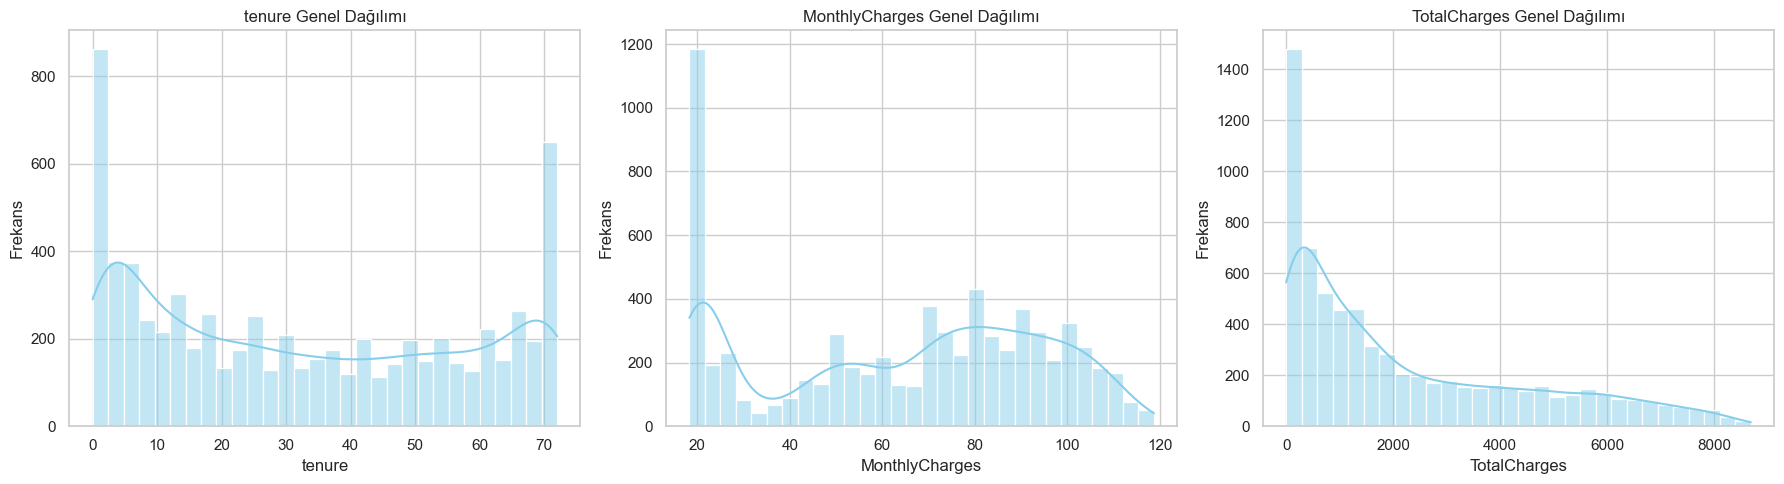

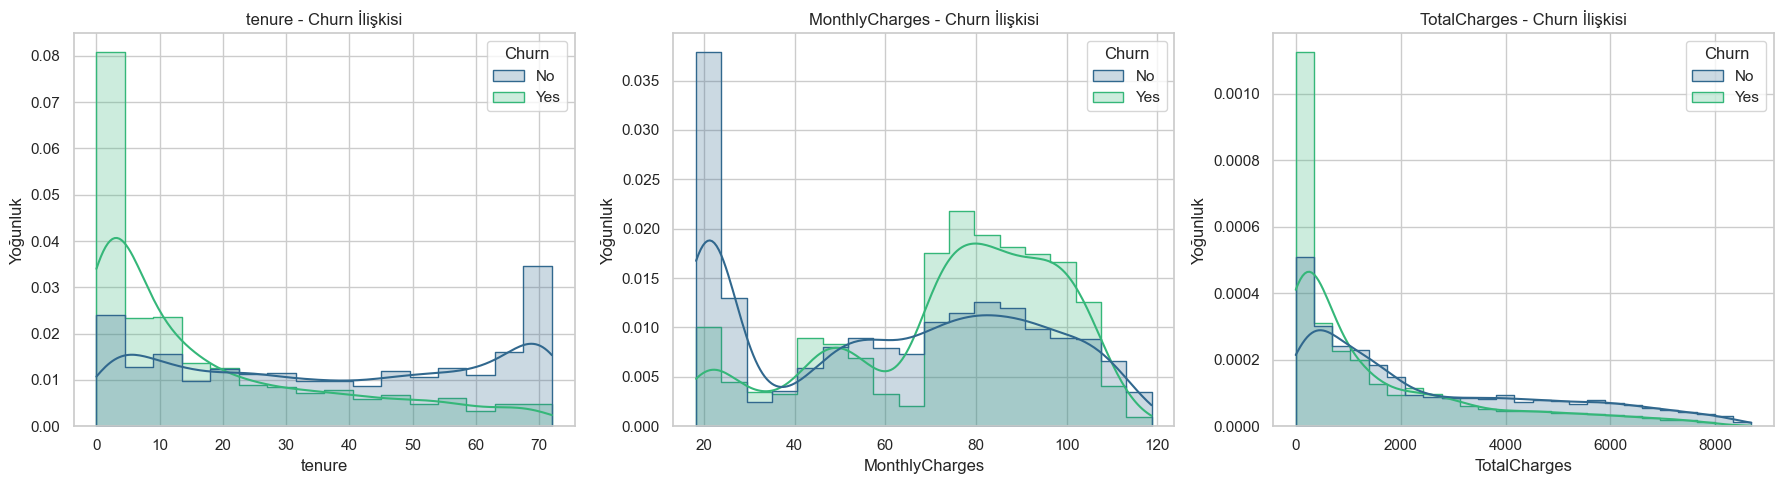

In [18]:
# Görselleştirme stilini ayarlayalım
sns.set(style="whitegrid")

# Analiz edilecek sayısal sütunlar
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# 1. TEKLİ DEĞİŞKEN ANALİZİ: Genel Dağılım (Histogram)
# Bu kısım, verinin genel yapısını (sola mı yatık, sağa mı, ortada mı toplanmış) gösterir.
plt.figure(figsize=(18, 5))

for i, col in enumerate(numeric_cols):
    plt.subplot(1, 3, i + 1)
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'{col} Genel Dağılımı')
    plt.xlabel(col)
    plt.ylabel('Frekans')

plt.tight_layout()
plt.show()

# 2. ÇOKLU DEĞİŞKEN ANALİZİ: Churn'e Göre Dağılım (Histogram + KDE)
# Bu kısım, ayrılan (Yes) ve kalan (No) müşterilerin farkını ortaya koyar.
plt.figure(figsize=(18, 5))

for i, col in enumerate(numeric_cols):
    plt.subplot(1, 3, i + 1)
    # hue='Churn' parametresi, veriyi Churn durumuna göre renklendirir
    sns.histplot(data=df, x=col, hue='Churn', kde=True, element="step", stat="density", common_norm=False, palette='viridis')
    plt.title(f'{col} - Churn İlişkisi')
    plt.xlabel(col)
    plt.ylabel('Yoğunluk')

plt.tight_layout()
plt.show()

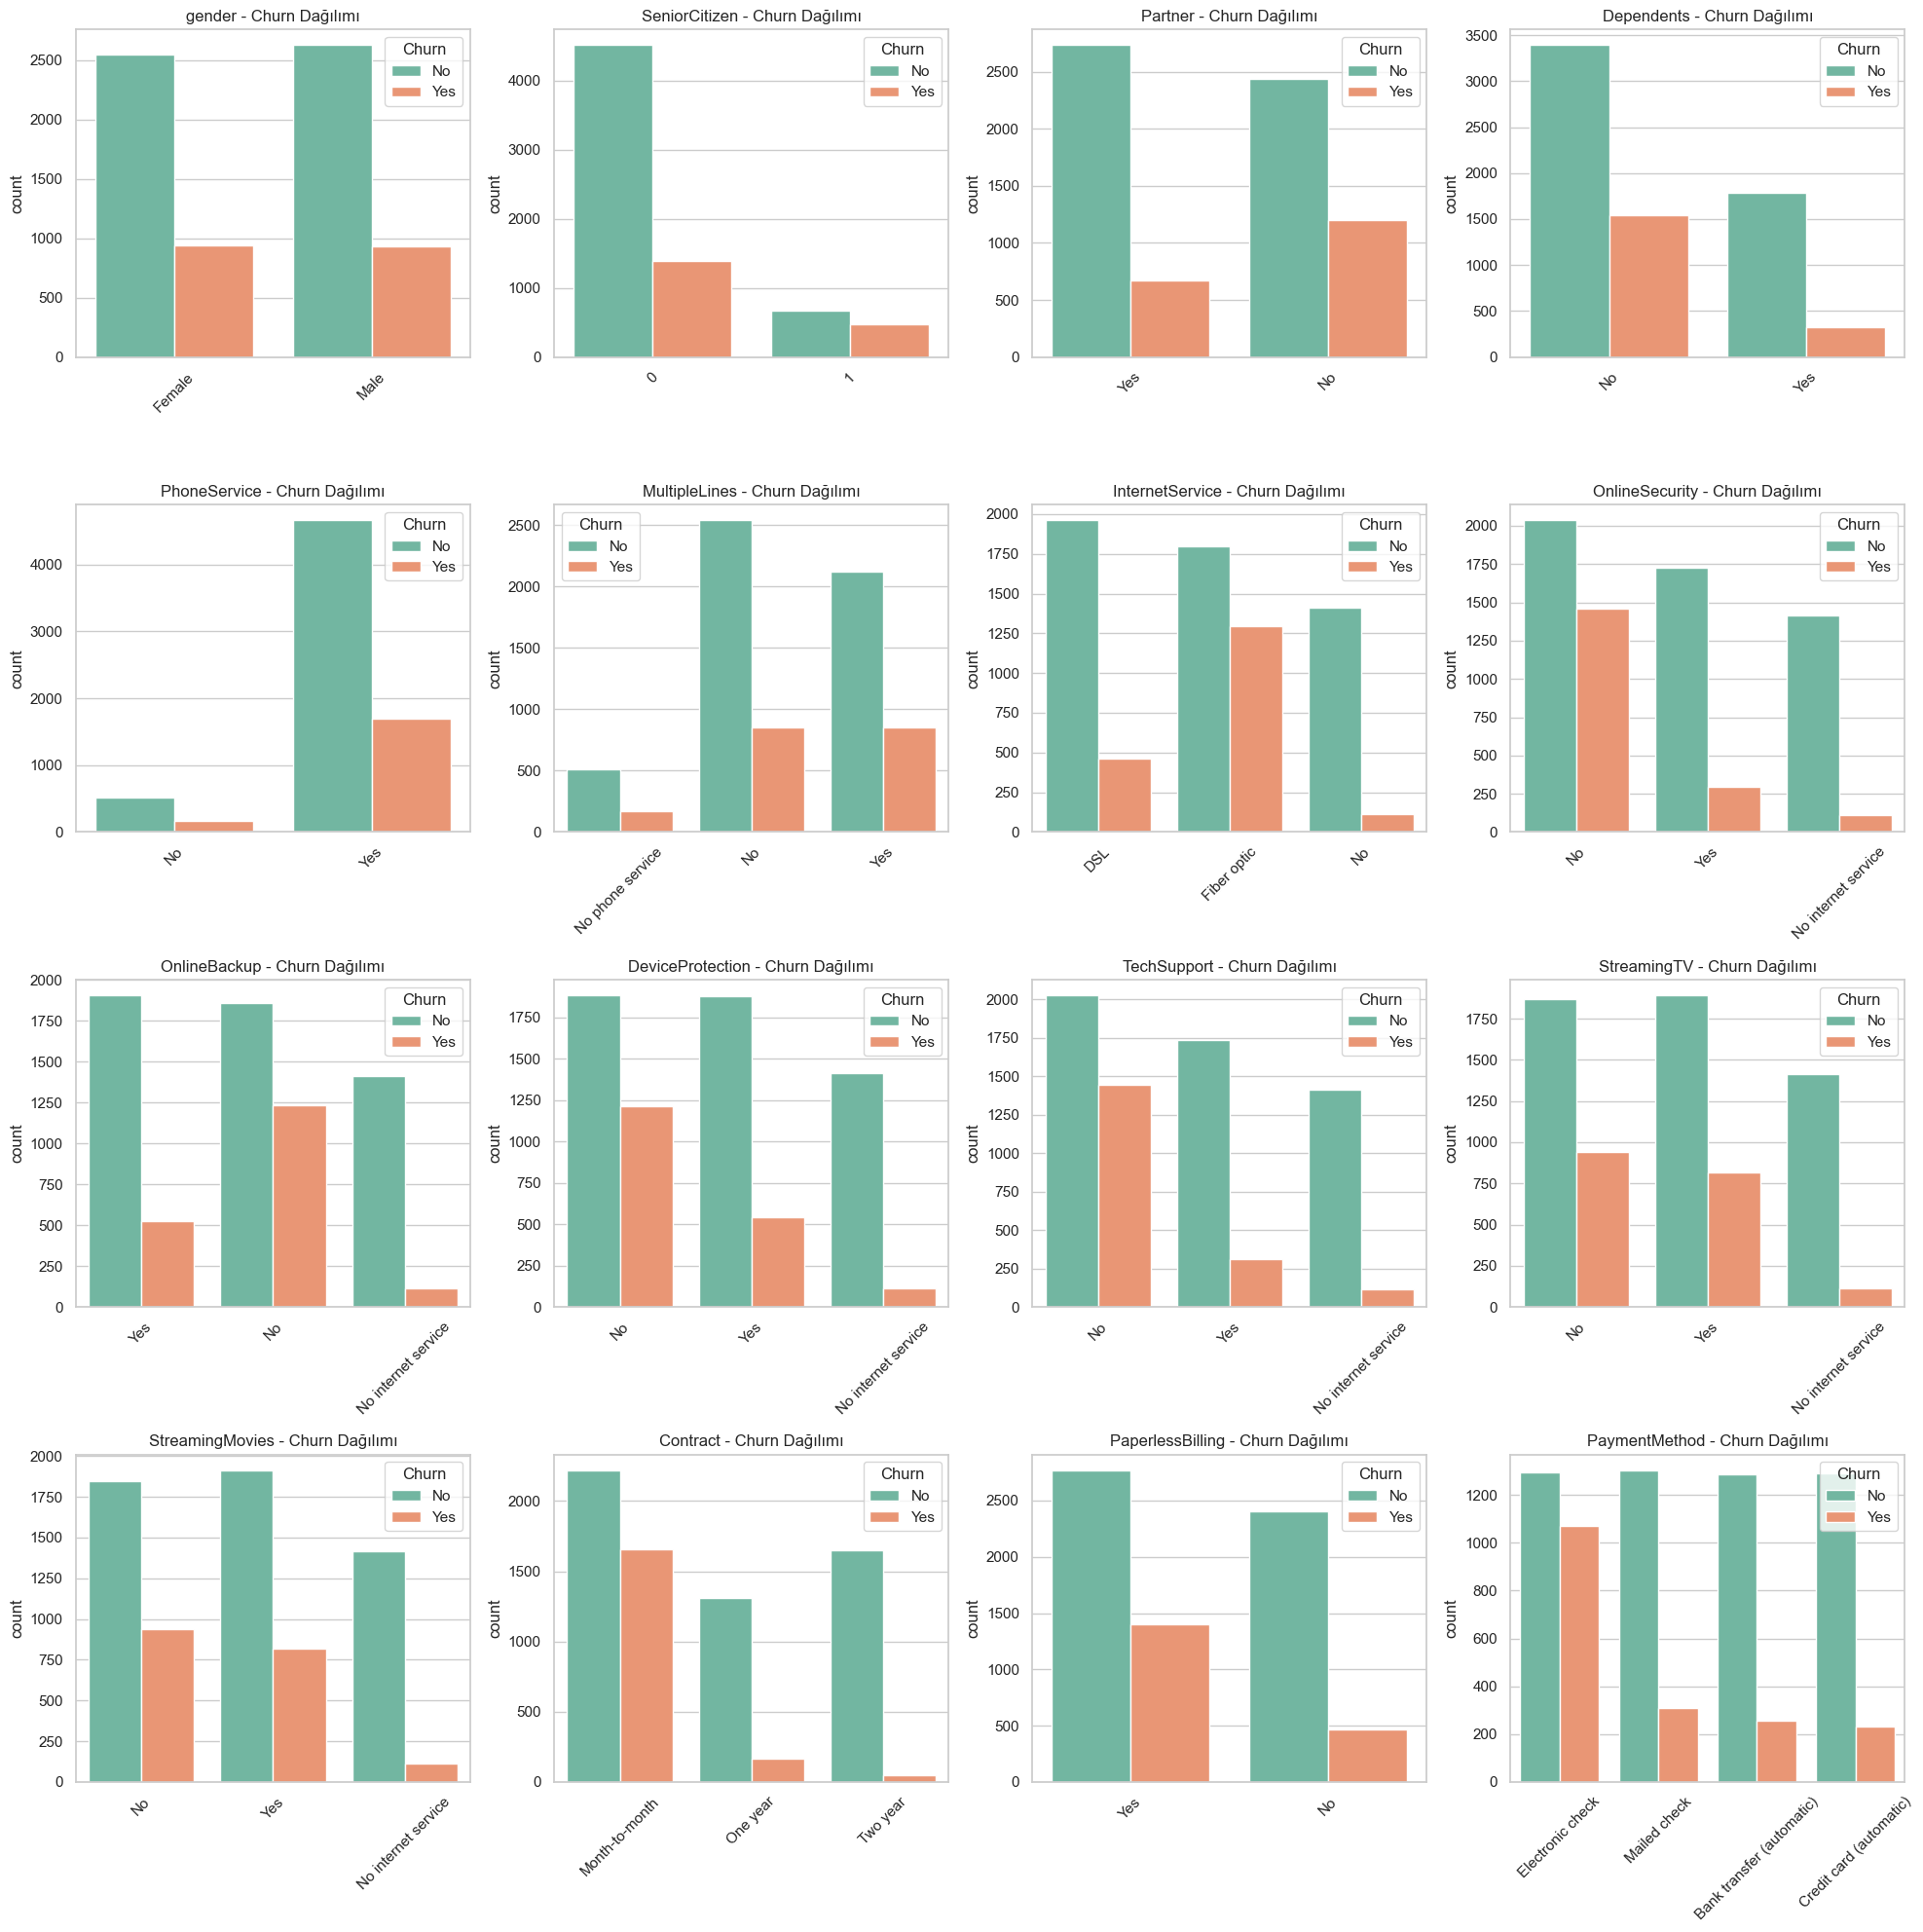

In [19]:
# Görselleştirme stilini ayarlayalım
sns.set(style="whitegrid")

# Analiz edilecek ana kategorik değişkenler
# Bu değişkenler müşterinin profilini ve satın aldığı hizmetleri gösterir
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 
            'PhoneService', 'MultipleLines', 'InternetService', 
            'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
            'TechSupport', 'StreamingTV', 'StreamingMovies', 
            'Contract', 'PaperlessBilling', 'PaymentMethod']

# Çok sayıda grafik olacağı için döngü ile çizdirmek en temiz yoldur.
# 4 satır ve 4 sütunluk bir tablo (grid) oluşturalım
fig, axes = plt.subplots(4, 4, figsize=(20, 20))
axes = axes.flatten() # Eksenleri tek boyutlu listeye çevirir (döngü kolaylığı için)

for i, col in enumerate(cat_cols):
    # hue='Churn' parametresi ile ayrılan ve kalanları renklerle ayırıyoruz
    sns.countplot(x=col, hue='Churn', data=df, ax=axes[i], palette='Set2')
    
    # Başlık ve eksen ayarları
    axes[i].set_title(f'{col} - Churn Dağılımı')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45) # Yazıların üst üste binmemesi için eğik yaz

# Düzenin sıkışık olmaması için
plt.tight_layout()
plt.show()

In [20]:
multi_cat_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                  'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                  'Contract', 'PaymentMethod', 'tenure_segment']

In [24]:
df['tenure_segment'] = pd.cut(
    df['tenure'],
    bins=[0, 6, 12, 24, 48, 72],
    labels=['0-6ay', '6-12ay', '1-2yil', '2-4yil', '4yil+'],
    include_lowest=True
).astype(str)

In [25]:
# ─────────────────────────────────────────────
# 1.5 ÖZELLİK MÜHENDİSLİĞİ
# ─────────────────────────────────────────────

df['tenure_segment'] = pd.cut(
    df['tenure'],
    bins=[0, 6, 12, 24, 48, 72],
    labels=['0-6ay', '6-12ay', '1-2yil', '2-4yil', '4yil+'],
    include_lowest=True
).astype(str)

df['ucret_per_tenure'] = df['MonthlyCharges'] / (df['tenure'] + 1)

df['harcama_farki'] = df['TotalCharges'] - (df['MonthlyCharges'] * df['tenure'])

hizmet_kolonlari = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                    'TechSupport', 'StreamingTV', 'StreamingMovies']
df['hizmet_sayisi'] = df[hizmet_kolonlari].apply(
    lambda x: x.str.contains('Yes', na=False).sum(), axis=1
)

df['ucret_per_hizmet'] = df['MonthlyCharges'] / (df['hizmet_sayisi'] + 1)

df['risk_kombinasyon'] = (
    (df['Contract'] == 'Month-to-month') &
    (df['MonthlyCharges'] > df['MonthlyCharges'].median())
).astype(int)

In [26]:
from sklearn.preprocessing import MinMaxScaler, LabelEncoder 

# 1. VERİYİ YÜKLEME VE TEMİZLEME (Hata almamak için baştan alıyoruz)
df = pd.read_csv('musteri_kayip.csv')

# TotalCharges temizliği
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

# customerID gereksiz
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)

# 2. ENCODING (KATEGORİK -> SAYISAL)

# A) Binary (İki seçenekli) Değişkenler için Label Encoding
le = LabelEncoder()
binary_cols = [col for col in df.columns if df[col].dtype == 'object' and df[col].nunique() == 2]

print("Label Encoding Yapılan Sütunlar:\n", binary_cols)

for col in binary_cols:
    df[col] = le.fit_transform(df[col])

# B) Multi-Class (Çok seçenekli) Değişkenler için One-Hot Encoding
# drop_first=True diyerek gereksiz kolon tekrarından kaçınıyoruz
df = pd.get_dummies(df, drop_first=True)

# 3. SCALING (ÖLÇEKLENDİRME)
# Verilerimiz normal dağılmadığı için MinMaxScaler kullanıyoruz
scaler = MinMaxScaler()
cols_to_scale = ['tenure', 'MonthlyCharges', 'TotalCharges']

df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])


# SONUÇLARI GÖRELİM
print("\n--- İşlenmiş Veri Seti Boyutu ---")
print(df.shape)
print("\n--- İlk 5 Satır ---")
print(df.head())

Label Encoding Yapılan Sütunlar:
 ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

--- İşlenmiş Veri Seti Boyutu ---
(7043, 31)

--- İlk 5 Satır ---
   gender  SeniorCitizen  Partner  Dependents    tenure  PhoneService  \
0       0              0        1           0  0.013889             0   
1       1              0        0           0  0.472222             1   
2       1              0        0           0  0.027778             1   
3       1              0        0           0  0.625000             0   
4       0              0        0           0  0.027778             1   

   PaperlessBilling  MonthlyCharges  TotalCharges  Churn  ...  \
0                 1        0.115423      0.003437      0  ...   
1                 0        0.385075      0.217564      0  ...   
2                 1        0.354229      0.012453      1  ...   
3                 0        0.239303      0.211951      0  ...   
4                 1        0.521891      0.017462     

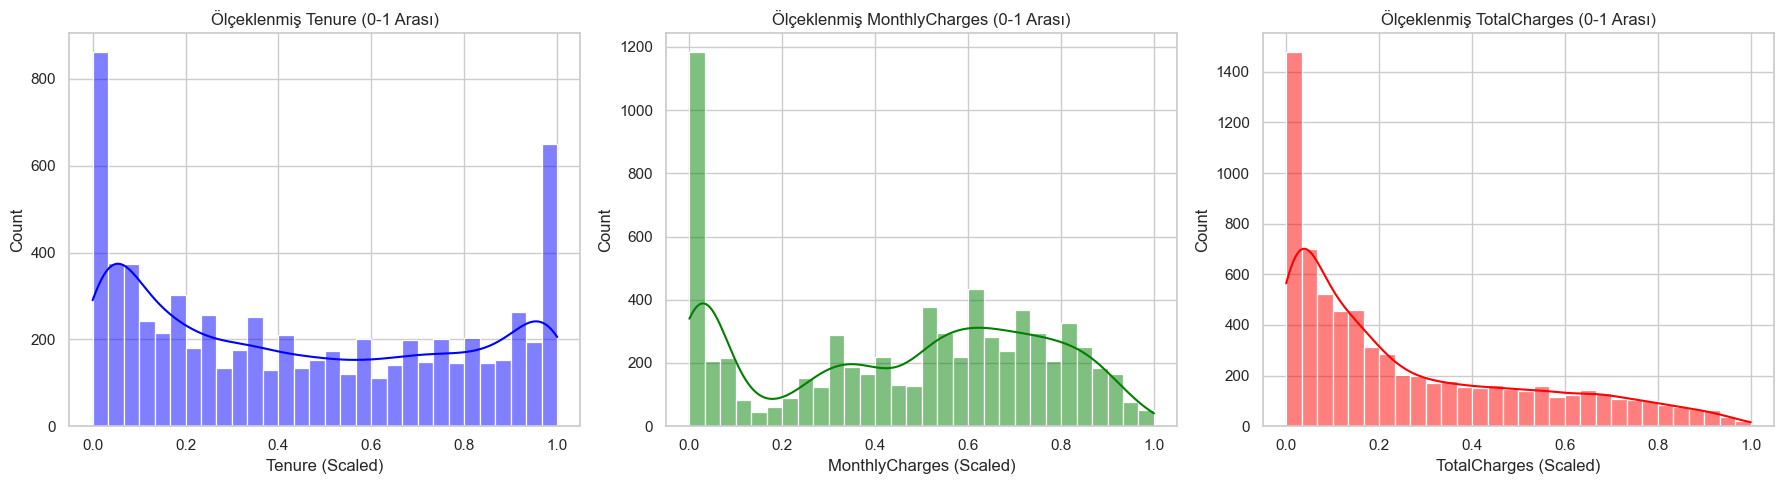

In [27]:
# Daha önce oluşturduğumuz ölçeklenmiş 'df' veri setini kullanıyoruz.
# (Eğer df kaybolduysa yukarıdaki kod bloğunu tekrar çalıştırmalısın)

plt.figure(figsize=(18, 5))

# 1. Ölçeklenmiş Tenure (Abonelik Süresi)
plt.subplot(1, 3, 1)
sns.histplot(df['tenure'], kde=True, color='blue', bins=30)
plt.title('Ölçeklenmiş Tenure (0-1 Arası)')
plt.xlabel('Tenure (Scaled)')

# 2. Ölçeklenmiş MonthlyCharges (Aylık Ücret)
plt.subplot(1, 3, 2)
sns.histplot(df['MonthlyCharges'], kde=True, color='green', bins=30)
plt.title('Ölçeklenmiş MonthlyCharges (0-1 Arası)')
plt.xlabel('MonthlyCharges (Scaled)')

# 3. Ölçeklenmiş TotalCharges (Toplam Ücret)
plt.subplot(1, 3, 3)
sns.histplot(df['TotalCharges'], kde=True, color='red', bins=30)
plt.title('Ölçeklenmiş TotalCharges (0-1 Arası)')
plt.xlabel('TotalCharges (Scaled)')

plt.tight_layout()
plt.show()

--- CHURN İLE EN YÜKSEK POZİTİF İLİŞKİSİ OLANLAR (Müşteri Kaybettirenler) ---
Churn                             1.000000
InternetService_Fiber optic       0.308020
PaymentMethod_Electronic check    0.301919
MonthlyCharges                    0.193356
PaperlessBilling                  0.191825
SeniorCitizen                     0.150889
Name: Churn, dtype: float64

--- CHURN İLE EN YÜKSEK NEGATİF İLİŞKİSİ OLANLAR (Müşteri Tutanlar) ---
TechSupport_No internet service       -0.227890
StreamingTV_No internet service       -0.227890
StreamingMovies_No internet service   -0.227890
Contract_Two year                     -0.302253
tenure                                -0.352229
Name: Churn, dtype: float64


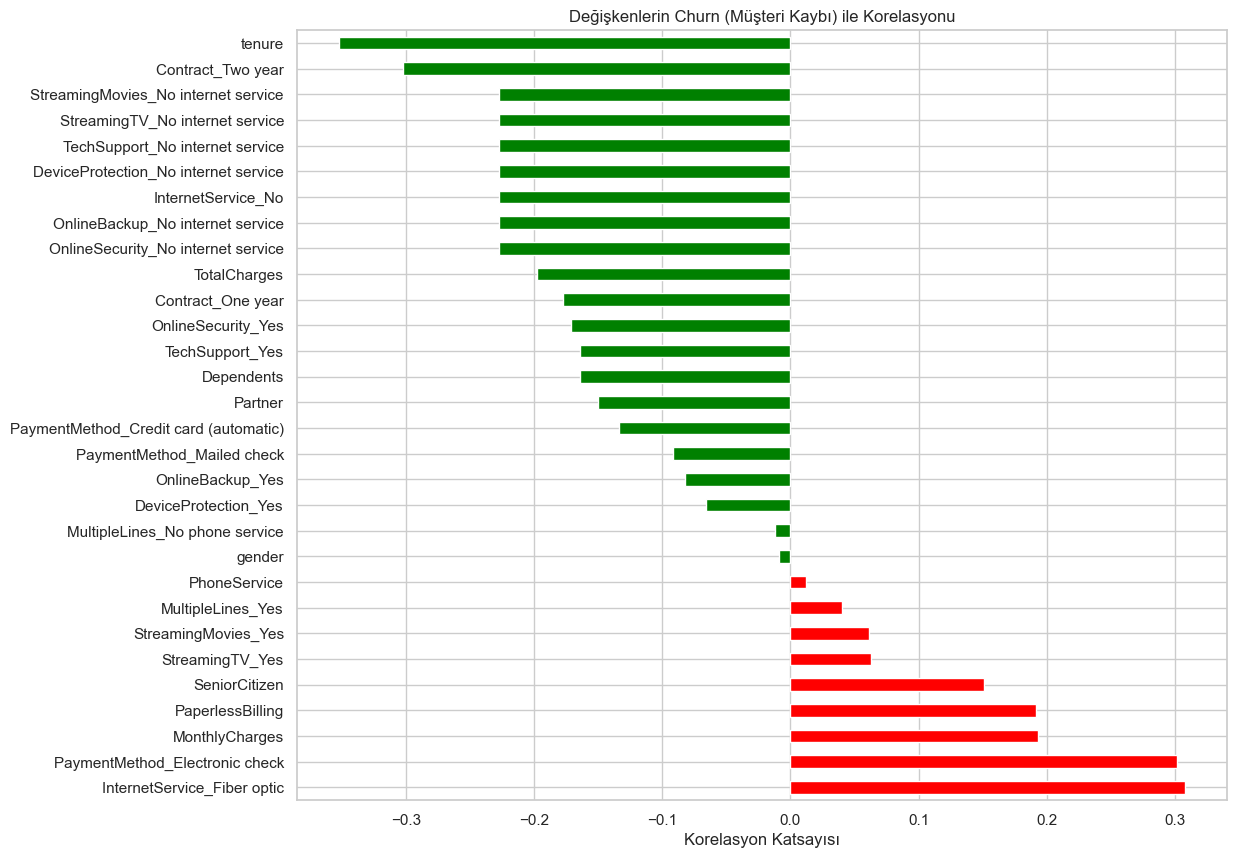

In [28]:
# Encoding (Label Encoding - Binary)
le = LabelEncoder()
binary_cols = [col for col in df.columns if df[col].dtype == 'object' and df[col].nunique() == 2]
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

# Encoding (One-Hot Encoding - Multi-class)
df = pd.get_dummies(df, drop_first=True)

# Scaling (İsteğe bağlı ama model için gerekli, korelasyonu etkilemez ama hazır olsun)
scaler = MinMaxScaler()
cols_to_scale = ['tenure', 'MonthlyCharges', 'TotalCharges']
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

# 2. KORELASYON ANALİZİ
# Hedef değişkenimiz 'Churn' ile diğer tüm değişkenlerin ilişkisi
correlation = df.corr()['Churn'].sort_values(ascending=False)

# İlk 5 (En çok kaybettirenler) ve Son 5 (En çok tutanlar)
print("--- CHURN İLE EN YÜKSEK POZİTİF İLİŞKİSİ OLANLAR (Müşteri Kaybettirenler) ---")
print(correlation.head(6)) # İlk sırada Churn'ün kendisi olacağı için 6 aldık

print("\n--- CHURN İLE EN YÜKSEK NEGATİF İLİŞKİSİ OLANLAR (Müşteri Tutanlar) ---")
print(correlation.tail(5))

# 3. GÖRSELLEŞTİRME (Bar Plot)
plt.figure(figsize=(12, 10))
# Churn'ün kendisini grafikten çıkarıyoruz (korelasyonu 1.0 olduğu için)
correlation.drop('Churn').plot(kind='barh', color=correlation.drop('Churn').apply(lambda x: 'red' if x > 0 else 'green'))
plt.title('Değişkenlerin Churn (Müşteri Kaybı) ile Korelasyonu')
plt.xlabel('Korelasyon Katsayısı')
plt.show()

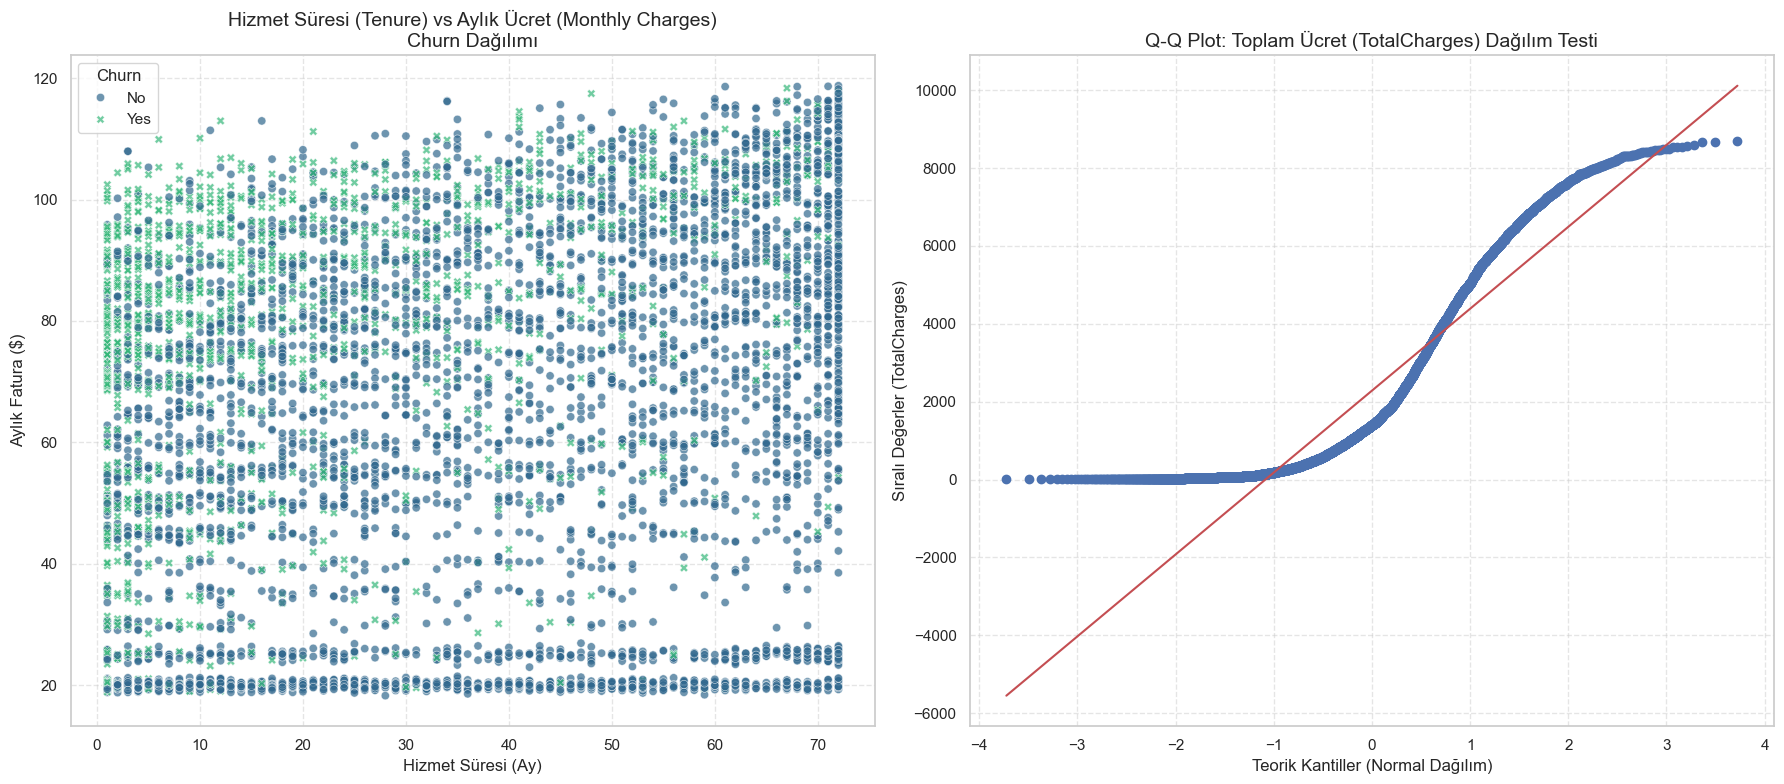

In [29]:
# Veri setini yükleme
df = pd.read_csv('musteri_kayip.csv')

# 'TotalCharges' sütunundaki boşlukları temizleyip sayısal veriye çevirme
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(subset=['TotalCharges'], inplace=True) # Eksik verileri temizleme

# Grafik ayarları
plt.figure(figsize=(18, 8))

# --- 1. SCATTER PLOT (Saçılım Grafiği) ---
# Amaç: Hizmet süresi ve Fatura tutarı arasındaki ilişkinin Churn üzerindeki etkisini görmek.
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='tenure', y='MonthlyCharges', hue='Churn', style='Churn', palette='viridis', alpha=0.7)
plt.title('Hizmet Süresi (Tenure) vs Aylık Ücret (Monthly Charges)\nChurn Dağılımı', fontsize=14)
plt.xlabel('Hizmet Süresi (Ay)', fontsize=12)
plt.ylabel('Aylık Fatura ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# --- 2. QUANTILE PLOT (Q-Q Plot) ---
# Amaç: TotalCharges değişkeninin normal dağılıma uygunluğunu test etmek.
plt.subplot(1, 2, 2)
stats.probplot(df['TotalCharges'], dist="norm", plot=plt)
plt.title('Q-Q Plot: Toplam Ücret (TotalCharges) Dağılım Testi', fontsize=14)
plt.xlabel('Teorik Kantiller (Normal Dağılım)', fontsize=12)
plt.ylabel('Sıralı Değerler (TotalCharges)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [30]:
# 2. TotalCharges sütunundaki boşlukları (string) 0 ile doldurup sayısal tipe çevirme
# (Veri setinde 11 satırda boşluk karakteri mevcuttu)
df['TotalCharges'] = df['TotalCharges'].replace(' ', '0')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

# 3. Label Encoding (Sadece 2 kategorisi olan değişkenler için)
# Bu işlem Yes/No veya Male/Female gibi ikili değerleri 0 ve 1 yapar.
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
le = LabelEncoder()

for col in binary_cols:
    df[col] = le.fit_transform(df[col])

# 4. One-Hot Encoding (3 veya daha fazla kategorisi olan değişkenler için)
# Bu işlem her kategoriyi yeni bir sütun yapar (Kukla Değişkenler).
multi_cat_cols = [
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 
    'Contract', 'PaymentMethod'
]

# drop_first=True: İlk kategoriyi atarak 'kukla değişken tuzağını' önler ve modelin daha verimli çalışmasını sağlar.
df_final = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True)

# 5. Model için anlamsız olan customerID sütununu kaldırma
df_final = df_final.drop('customerID', axis=1)

# Sonucu inceleme
print(f"İşlem sonrası veri seti boyutu: {df_final.shape}")
print(df_final.head())

İşlem sonrası veri seti boyutu: (7032, 31)
   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       0              0        1           0       1             0   
1       1              0        0           0      34             1   
2       1              0        0           0       2             1   
3       1              0        0           0      45             0   
4       0              0        0           0       2             1   

   PaperlessBilling  MonthlyCharges  TotalCharges  Churn  ...  \
0                 1           29.85         29.85      0  ...   
1                 0           56.95       1889.50      0  ...   
2                 1           53.85        108.15      1  ...   
3                 0           42.30       1840.75      0  ...   
4                 1           70.70        151.65      1  ...   

   TechSupport_Yes  StreamingTV_No internet service  StreamingTV_Yes  \
0                0                                0                

In [31]:
# 1. Özellikleri (X) ve Hedef Değişkeni (y) Ayırma
# 'Churn' bizim tahmin etmek istediğimiz değer, diğerleri girdilerimizdir.
X = df_final.drop('Churn', axis=1)
y = df_final['Churn']

# 2. Train-Test Split (Veriyi Bölme)
# Verinin %80'ini eğitim, %20'sini test için ayırıyoruz. 
# random_state=42, sonuçların her çalıştırdığınızda aynı çıkmasını sağlar.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 3. Feature Scaling (Ölçeklendirme)
# Bazı sütunlar (MonthlyCharges, TotalCharges, tenure) çok yüksek değerlere sahipken,
# encoding yaptığımız sütunlar sadece 0 ve 1'den oluşuyor.
# StandardScaler, sayısal değerleri ortalaması 0, standart sapması 1 olacak şekilde dönüştürür.

scaler = StandardScaler()

# Sadece sayısal (sürekli) sütunları ölçeklendirmek daha sağlıklıdır 
# Ancak tüm X setine uygulamak da modellerin çoğunda sorun yaratmaz.
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Eğitim seti boyutu:", X_train.shape)
print("Test seti boyutu:", X_test.shape)

Eğitim seti boyutu: (5625, 30)
Test seti boyutu: (1407, 30)


In [32]:


# 1. Veriyi Ayırma (X: Özellikler, y: Hedef)
X = df_final.drop('Churn', axis=1)
y = df_final['Churn']

# 2. Train-Test Split (Veriyi Bölme)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 3. Feature Scaling (Ölçeklendirme)
# Burada X_train_scaled ve X_test_scaled değişkenlerini tanımlıyoruz
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Decision Tree Modelini Tanımlama ve Eğitme
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)

# 5. Tahmin Yapma
y_pred_dt = dt_model.predict(X_test_scaled)

# 6. Sonuçları Görüntüleme
print(f"Decision Tree Doğruluğu: {accuracy_score(y_test, y_pred_dt):.4f}")
print("\nKarmaşıklık Matrisi:")
print(confusion_matrix(y_test, y_pred_dt))
print("\nSınıflandırma Raporu:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Doğruluğu: 0.7264

Karmaşıklık Matrisi:
[[830 203]
 [182 192]]

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.82      0.80      0.81      1033
           1       0.49      0.51      0.50       374

    accuracy                           0.73      1407
   macro avg       0.65      0.66      0.66      1407
weighted avg       0.73      0.73      0.73      1407



In [33]:
from sklearn.tree import DecisionTreeClassifier

# class_weight='balanced' eklemek yeterlidir
model_balanced = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
model_balanced.fit(X_train_scaled, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42)

In [34]:
# Tahmin yap
y_pred_balanced = model_balanced.predict(X_test_scaled)

# Sonuçları görüntüle
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred_balanced))
print(confusion_matrix(y_test, y_pred_balanced))

              precision    recall  f1-score   support

           0       0.92      0.63      0.75      1033
           1       0.45      0.84      0.59       374

    accuracy                           0.69      1407
   macro avg       0.69      0.74      0.67      1407
weighted avg       0.79      0.69      0.71      1407

[[654 379]
 [ 59 315]]


In [35]:
# 1. SMOTE Uygulaması (Sadece Eğitim Setine!)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

# SMOTE öncesi ve sonrası dağılımı görelim:
print("SMOTE Öncesi Eğitim Seti Dağılımı:")
print(y_train.value_counts())
print("\nSMOTE Sonrası Eğitim Seti Dağılımı:")
print(y_train_smote.value_counts())
print("-" * 40)

# 2. Modeli Eğitme (Artık scale_pos_weight kullanmıyoruz çünkü veri dengelendi!)
# Basit bir XGBoost modeli kuruyoruz
smote_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

# Modeli SMOTE ile eşitlenmiş veride eğitiyoruz
smote_model.fit(X_train_smote, y_train_smote)

# 3. Tahmin (Orijinal, dokunulmamış test verisi üzerinde!)
y_pred_smote = smote_model.predict(X_test_scaled)

# 4. Sonuçlar
print("\n--- SMOTE Destekli Sınıflandırma Raporu ---")
print(classification_report(y_test, y_pred_smote))

print("\n--- Karmaşıklık Matrisi ---")
print(confusion_matrix(y_test, y_pred_smote))

c:\Users\oguzz\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


SMOTE Öncesi Eğitim Seti Dağılımı:
0    4130
1    1495
Name: Churn, dtype: int64

SMOTE Sonrası Eğitim Seti Dağılımı:
1    4130
0    4130
Name: Churn, dtype: int64
----------------------------------------

--- SMOTE Destekli Sınıflandırma Raporu ---
              precision    recall  f1-score   support

           0       0.87      0.83      0.85      1033
           1       0.57      0.64      0.61       374

    accuracy                           0.78      1407
   macro avg       0.72      0.74      0.73      1407
weighted avg       0.79      0.78      0.78      1407


--- Karmaşıklık Matrisi ---
[[854 179]
 [133 241]]


In [36]:
# 1. Sınıf dengesizliğini çözmek için oran hesaplama
# (Notebook'taki y_train değişkeni kullanılıyor)
negative_class_count = (y_train == 0).sum()
positive_class_count = (y_train == 1).sum()
scale_weight = negative_class_count / positive_class_count

# 2. XGBoost Modelini Tanımlama
xgb_model = xgb.XGBClassifier(
    scale_pos_weight=scale_weight,
    n_estimators=100,         
    max_depth=5,              
    learning_rate=0.1,        
    random_state=42,
    eval_metric='logloss'     
)

# 3. Modeli Eğitme 
# (Notebook'taki doğru değişken olan X_train_scaled kullanılıyor)
xgb_model.fit(X_train_scaled, y_train)

# 4. Test Seti Üzerinde Tahmin Yapma
# (Notebook'taki doğru değişken olan X_test_scaled kullanılıyor)
y_pred_xgb = xgb_model.predict(X_test_scaled)

# 5. Sonuçları Görüntüleme
print("--- XGBoost Sınıflandırma Raporu ---")
print(classification_report(y_test, y_pred_xgb))

print("\n--- Karmaşıklık Matrisi (Confusion Matrix) ---")
print(confusion_matrix(y_test, y_pred_xgb))

--- XGBoost Sınıflandırma Raporu ---
              precision    recall  f1-score   support

           0       0.89      0.72      0.80      1033
           1       0.50      0.76      0.60       374

    accuracy                           0.73      1407
   macro avg       0.69      0.74      0.70      1407
weighted avg       0.79      0.73      0.74      1407


--- Karmaşıklık Matrisi (Confusion Matrix) ---
[[742 291]
 [ 88 286]]


In [37]:
# 1. Modelin direkt 1/0 tahmini yerine, olasılık değerlerini (0.0 ile 1.0 arası) alalım
y_pred_proba = xgb_model.predict_proba(X_test_scaled)[:, 1] # Sadece 1 (Churn) olma olasılıkları

# 2. Yeni bir Karar Eşiği (Threshold) belirleyelim (Örn: %65 emin olmadan 1 deme)
yeni_esik_degeri = 0.65

# 3. Olasılık bu eşikten büyükse 1, değilse 0 yap
y_pred_high_precision = (y_pred_proba >= yeni_esik_degeri).astype(int)

# 4. Yeni Sonuçları Görelim
print(f"--- Eşik Değeri {yeni_esik_degeri} Olarak Ayarlandığında Sonuçlar ---")
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred_high_precision))
print("\nKarmaşıklık Matrisi:")
print(confusion_matrix(y_test, y_pred_high_precision))

--- Eşik Değeri 0.65 Olarak Ayarlandığında Sonuçlar ---
              precision    recall  f1-score   support

           0       0.86      0.84      0.85      1033
           1       0.59      0.63      0.61       374

    accuracy                           0.78      1407
   macro avg       0.72      0.74      0.73      1407
weighted avg       0.79      0.78      0.79      1407


Karmaşıklık Matrisi:
[[867 166]
 [138 236]]


In [38]:
# 1. VERİYİ YÜKLE VE TEMİZLE
df = pd.read_csv('musteri_kayip.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
if 'customerID' in df.columns:
    df = df.drop('customerID', axis=1)

# 2. ENCODING (Kategorik verileri sayısallaştırma)
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

multi_cat_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 
                  'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 
                  'Contract', 'PaymentMethod']
df_final = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True)

# 3. VERİYİ AYIRMA
X = df_final.drop('Churn', axis=1)
y = df_final['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 4. ÖLÇEKLENDİRME
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. CATBOOST MODELİNİ KURMA
# CatBoost'un gücü: auto_class_weights='Balanced' ile dengesizliği otomatik çözer.
cat_model = CatBoostClassifier(
    iterations=200,                # Ağaç sayısı (CatBoost çok hızlıdır, 200 idealdir)
    learning_rate=0.05,            # Öğrenme hızı (daha sindirerek öğrenmesi için biraz düşürdük)
    depth=6,                       # Ağaç derinliği
    auto_class_weights='Balanced', # Dengesiz veriyi otomatik dengeler!
    verbose=0,                     # Çalışırken ekrana yüzlerce satır log basmasını engeller
    random_state=42
)

# 6. EĞİTİM VE TAHMİN
cat_model.fit(X_train_scaled, y_train)
y_pred_cat = cat_model.predict(X_test_scaled)

# 7. SONUÇLARI YAZDIR
print("--- CatBoost Sınıflandırma Raporu ---")
print(classification_report(y_test, y_pred_cat))

print("\n--- Karmaşıklık Matrisi (Confusion Matrix) ---")
print(confusion_matrix(y_test, y_pred_cat))

--- CatBoost Sınıflandırma Raporu ---
              precision    recall  f1-score   support

           0       0.92      0.75      0.82      1036
           1       0.54      0.83      0.65       373

    accuracy                           0.77      1409
   macro avg       0.73      0.79      0.74      1409
weighted avg       0.82      0.77      0.78      1409


--- Karmaşıklık Matrisi (Confusion Matrix) ---
[[772 264]
 [ 65 308]]


✅ Optimal eşik  : 0.153
💰 Minimum maliyet: 33,100 TL

--- Optimal Eşikli Sınıflandırma Raporu ---
              precision    recall  f1-score   support

           0       0.98      0.43      0.60      1036
           1       0.38      0.98      0.55       373

    accuracy                           0.57      1409
   macro avg       0.68      0.70      0.57      1409
weighted avg       0.82      0.57      0.58      1409


--- Optimal Eşikli Confusion Matrix ---
[[444 592]
 [  7 366]]

--- Müşteri Segment Dağılımı ---
               musteri_sayisi  ort_kayip_olasiligi  gercek_kayip_sayisi
segment                                                                
🟢 Güvenli                 637                0.109                   28
🟡 Riskli                  330                0.453                   81
🔴 Yüksek Risk             442                0.781                  264

╔══════════════╦═══════════════════════════════════════════╦══════════════════════╗
║ Segment      ║ Aksiyon        

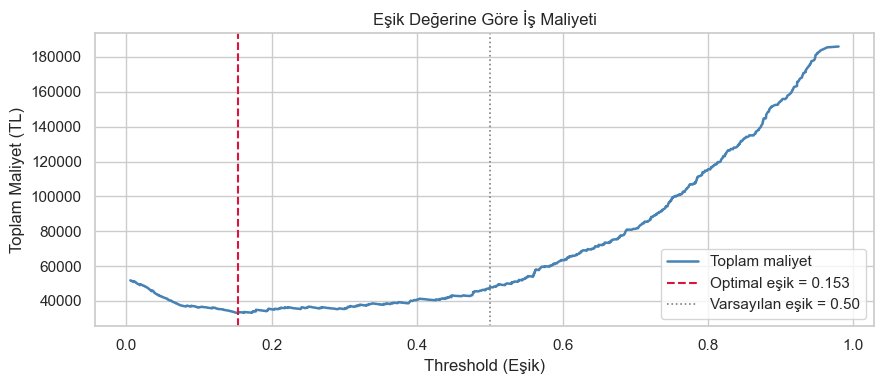

In [75]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, classification_report, confusion_matrix

# ─────────────────────────────────────────────
# 8. THRESHOLD OPTİMİZASYONU
# ─────────────────────────────────────────────

# Olasılıkları al (sadece pozitif sınıf = kayacak)
y_proba = cat_model.predict_proba(X_test_scaled)[:, 1]

# ── İŞ MALİYETLERİNİ TANIMLA ──────────────────
# Bu iki sayıyı kendi şirketine göre değiştir!
PROMOSYON_MALIYETI = 50     # TL — 1 FP'nin maliyeti (gereksiz promosyon)
MUSTERI_LTV_KAYBI  = 500    # TL — 1 FN'nin maliyeti (kaçırılan müşteri)
# ───────────────────────────────────────────────

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

# Her eşik için toplam iş maliyetini hesapla
costs = []
for thresh in thresholds:
    y_pred_temp = (y_proba >= thresh).astype(int)
    fp = ((y_pred_temp == 1) & (y_test == 0)).sum()
    fn = ((y_pred_temp == 0) & (y_test == 1)).sum()
    costs.append(fp * PROMOSYON_MALIYETI + fn * MUSTERI_LTV_KAYBI)

optimal_idx       = int(np.argmin(costs))
optimal_threshold = thresholds[optimal_idx]
print(f"✅ Optimal eşik  : {optimal_threshold:.3f}")
print(f"💰 Minimum maliyet: {min(costs):,} TL")

# ─────────────────────────────────────────────
# 9. OPTİMAL EŞİKLE YENİDEN TAHMİN
# ─────────────────────────────────────────────

y_pred_optimal = (y_proba >= optimal_threshold).astype(int)

print("\n--- Optimal Eşikli Sınıflandırma Raporu ---")
print(classification_report(y_test, y_pred_optimal))

print("\n--- Optimal Eşikli Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred_optimal))

# ─────────────────────────────────────────────
# 10. MÜŞTERİ SEGMENTASYONU
# ─────────────────────────────────────────────

# Test setini bir DataFrame'e dönüştür
df_result = X_test.copy()
df_result['kayip_olasiligi'] = y_proba
df_result['gercek_durum']    = y_test.values

# Üç segmente ayır
df_result['segment'] = pd.cut(
    y_proba,
    bins=[0.0, 0.30, 0.60, 1.0],
    labels=['🟢 Güvenli', '🟡 Riskli', '🔴 Yüksek Risk'],
    include_lowest=True
)

# Segment dağılımını göster
print("\n--- Müşteri Segment Dağılımı ---")
segment_ozet = df_result.groupby('segment', observed=True).agg(
    musteri_sayisi=('kayip_olasiligi', 'count'),
    ort_kayip_olasiligi=('kayip_olasiligi', 'mean'),
    gercek_kayip_sayisi=('gercek_durum', 'sum')
).round(3)
print(segment_ozet)

# Segment başına önerilen aksiyon
print("""
╔══════════════╦═══════════════════════════════════════════╦══════════════════════╗
║ Segment      ║ Aksiyon                                   ║ Maliyet Seviyesi     ║
╠══════════════╬═══════════════════════════════════════════╬══════════════════════╣
║ Güvenli      ║ Müdahale yok — rutin iletişim             ║ 0 TL                 ║
║ Riskli       ║ E-posta / bilgi SMS'i gönder              ║ Düşük                ║
║ Yüksek Risk  ║ Pahalı promosyon veya temsilci araması    ║ Yüksek (hedefli)     ║
╚══════════════╩═══════════════════════════════════════════╩══════════════════════╝
""")

# ─────────────────────────────────────────────
# 11. MALİYET EĞRİSİ GRAFİĞİ
# ─────────────────────────────────────────────

plt.figure(figsize=(9, 4))
plt.plot(thresholds, costs, color='steelblue', linewidth=1.8, label='Toplam maliyet')
plt.axvline(optimal_threshold, color='crimson', linestyle='--', linewidth=1.5,
            label=f'Optimal eşik = {optimal_threshold:.3f}')
plt.axvline(0.5, color='gray', linestyle=':', linewidth=1.2, label='Varsayılan eşik = 0.50')
plt.xlabel('Threshold (Eşik)')
plt.ylabel('Toplam Maliyet (TL)')
plt.title('Eşik Değerine Göre İş Maliyeti')
plt.legend()
plt.tight_layout()
plt.show()

In [76]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# MODEL
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    
    Dense(16, activation='relu'),
    Dropout(0.1),
    
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ERKEN DURDURMA — overfit'i önler
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# EĞİTİM
history = model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    class_weight={0: 1, 1: 3},  # dengesizliği elle dengele
    verbose=1
)

# TAHMİN
y_proba_nn = model.predict(X_test_scaled).flatten()
y_pred_nn = (y_proba_nn >= 0.5).astype(int)

print("--- Yapay Sinir Ağı Sınıflandırma Raporu ---")
print(classification_report(y_test, y_pred_nn))
print("\n--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred_nn))

Epoch 1/100
141/141 [==============================] - 1s 2ms/step - loss: 0.9733 - accuracy: 0.6177 - val_loss: 0.4989 - val_accuracy: 0.7365
Epoch 2/100
141/141 [==============================] - 0s 2ms/step - loss: 0.8578 - accuracy: 0.6880 - val_loss: 0.4909 - val_accuracy: 0.7267
Epoch 3/100
141/141 [==============================] - 0s 1ms/step - loss: 0.8188 - accuracy: 0.7193 - val_loss: 0.4912 - val_accuracy: 0.7276
Epoch 4/100
141/141 [==============================] - 0s 1ms/step - loss: 0.8154 - accuracy: 0.7140 - val_loss: 0.4887 - val_accuracy: 0.7400
Epoch 5/100
141/141 [==============================] - 0s 1ms/step - loss: 0.7848 - accuracy: 0.7240 - val_loss: 0.4767 - val_accuracy: 0.7409
Epoch 6/100
141/141 [==============================] - 0s 1ms/step - loss: 0.7778 - accuracy: 0.7346 - val_loss: 0.4851 - val_accuracy: 0.7365
Epoch 7/100
141/141 [==============================] - 0s 1ms/step - loss: 0.7816 - accuracy: 0.7275 - val_loss: 0.4767 - val_accuracy: 0.7445

In [77]:
print(classification_report(y_test, y_pred_nn))

              precision    recall  f1-score   support

           0       0.92      0.72      0.81      1036
           1       0.52      0.82      0.63       373

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.75      0.76      1409



In [78]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_recall_curve
import numpy as np

# 1. GELİŞTİRİLMİŞ MİMARİ
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.4),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(16, activation='relu'),
    Dropout(0.1),

    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 2. CALLBACKS
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,              # önceki 10'dan artırdık, daha fazla şans
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,               # plateau'da learning rate'i yarıya indir
    patience=5,
    min_lr=0.00001,
    verbose=1
)

# 3. EĞİTİM
history = model.fit(
    X_train_scaled, y_train,
    epochs=150,               # daha fazla epoch hakkı
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    class_weight={0: 1, 1: 3},
    verbose=1
)

# 4. THRESHOLD OPTİMİZASYONU
y_proba_nn = model.predict(X_test_scaled).flatten()

PROMOSYON_MALIYETI = 50
MUSTERI_LTV_KAYBI  = 500

precision_arr, recall_arr, thresholds = precision_recall_curve(y_test, y_proba_nn)

costs = []
for thresh in thresholds:
    y_pred_temp = (y_proba_nn >= thresh).astype(int)
    fp = ((y_pred_temp == 1) & (y_test == 0)).sum()
    fn = ((y_pred_temp == 0) & (y_test == 1)).sum()
    costs.append(fp * PROMOSYON_MALIYETI + fn * MUSTERI_LTV_KAYBI)

optimal_threshold = thresholds[int(np.argmin(costs))]
print(f"\nOptimal eşik : {optimal_threshold:.3f}")
print(f"Minimum maliyet: {min(costs):,} TL")

# 5. SONUÇLAR
y_pred_nn_optimal = (y_proba_nn >= optimal_threshold).astype(int)

print("\n--- Geliştirilmiş Sinir Ağı — Sınıflandırma Raporu ---")
print(classification_report(y_test, y_pred_nn_optimal))
print("\n--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred_nn_optimal))

Epoch 1/150
141/141 [==============================] - 1s 2ms/step - loss: 0.9807 - accuracy: 0.6026 - val_loss: 0.5633 - val_accuracy: 0.7107 - lr: 0.0010
Epoch 2/150
141/141 [==============================] - 0s 2ms/step - loss: 0.8524 - accuracy: 0.7098 - val_loss: 0.5137 - val_accuracy: 0.7329 - lr: 0.0010
Epoch 3/150
141/141 [==============================] - 0s 2ms/step - loss: 0.8250 - accuracy: 0.7129 - val_loss: 0.5045 - val_accuracy: 0.7356 - lr: 0.0010
Epoch 4/150
141/141 [==============================] - 0s 2ms/step - loss: 0.8188 - accuracy: 0.7278 - val_loss: 0.5118 - val_accuracy: 0.7382 - lr: 0.0010
Epoch 5/150
141/141 [==============================] - 0s 2ms/step - loss: 0.7990 - accuracy: 0.7264 - val_loss: 0.4956 - val_accuracy: 0.7498 - lr: 0.0010
Epoch 6/150
141/141 [==============================] - 0s 2ms/step - loss: 0.7865 - accuracy: 0.7304 - val_loss: 0.5009 - val_accuracy: 0.7365 - lr: 0.0010
Epoch 7/150
141/141 [==============================] - 0s 2ms/st

In [79]:
print(classification_report(y_test, y_pred_nn_optimal))
print(confusion_matrix(y_test, y_pred_nn_optimal))

              precision    recall  f1-score   support

           0       0.97      0.51      0.67      1036
           1       0.41      0.96      0.58       373

    accuracy                           0.63      1409
   macro avg       0.69      0.73      0.62      1409
weighted avg       0.82      0.63      0.64      1409

[[527 509]
 [ 16 357]]


In [80]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from catboost import CatBoostClassifier

# 1. YÜKLE VE TEMİZLE
df = pd.read_csv('musteri_kayip.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
if 'customerID' in df.columns:
    df = df.drop('customerID', axis=1)

print(df.columns.tolist())
print(df.shape)

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
(7043, 20)


In [81]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from catboost import CatBoostClassifier

# 1. YÜKLE VE TEMİZLE
df = pd.read_csv('musteri_kayip.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
if 'customerID' in df.columns:
    df = df.drop('customerID', axis=1)

# 2. ÖZELLİK MÜHENDİSLİĞİ
df['tenure_segment'] = pd.cut(
    df['tenure'],
    bins=[0, 6, 12, 24, 48, 72],
    labels=['0-6ay', '6-12ay', '1-2yil', '2-4yil', '4yil+'],
    include_lowest=True
).astype(str)

df['ucret_per_tenure']  = df['MonthlyCharges'] / (df['tenure'] + 1)
df['harcama_farki']     = df['TotalCharges'] - (df['MonthlyCharges'] * df['tenure'])

hizmet_kolonlari = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                    'TechSupport', 'StreamingTV', 'StreamingMovies']
df['hizmet_sayisi'] = df[hizmet_kolonlari].apply(
    lambda x: x.str.contains('Yes', na=False).sum(), axis=1
)

df['ucret_per_hizmet'] = df['MonthlyCharges'] / (df['hizmet_sayisi'] + 1)
df['risk_kombinasyon'] = (
    (df['Contract'] == 'Month-to-month') &
    (df['MonthlyCharges'] > df['MonthlyCharges'].median())
).astype(int)

# 3. ENCODING
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

multi_cat_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                  'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                  'Contract', 'PaymentMethod', 'tenure_segment']
df_final = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True)

# 4. VERİYİ AYIRMA
X = df_final.drop('Churn', axis=1)
y = df_final['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 5. ÖLÇEKLENDİRME
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# 6. CATBOOST
cat_model = CatBoostClassifier(
    iterations=200,
    learning_rate=0.05,
    depth=6,
    auto_class_weights='Balanced',
    verbose=0,
    random_state=42
)
cat_model.fit(X_train_scaled, y_train)
y_pred_cat = cat_model.predict(X_test_scaled)

print("--- CatBoost + Özellik Mühendisliği ---")
print(classification_report(y_test, y_pred_cat))
print(confusion_matrix(y_test, y_pred_cat))

--- CatBoost + Özellik Mühendisliği ---
              precision    recall  f1-score   support

           0       0.92      0.75      0.83      1036
           1       0.54      0.81      0.65       373

    accuracy                           0.77      1409
   macro avg       0.73      0.78      0.74      1409
weighted avg       0.82      0.77      0.78      1409

[[777 259]
 [ 70 303]]


In [82]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve
import numpy as np

# 1. MİMARİ
model_v2 = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.4),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(16, activation='relu'),
    Dropout(0.1),

    Dense(1, activation='sigmoid')
])

model_v2.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 2. CALLBACKS
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001)

# 3. EĞİTİM — ham veri + özellik mühendisliği ile
model_v2.fit(
    X_train_scaled, y_train,
    epochs=150,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    class_weight={0: 1, 1: 3},
    verbose=0  # log bastırıldı, sadece sonuç görelim
)

# 4. THRESHOLD OPTİMİZASYONU
y_proba_v2 = model_v2.predict(X_test_scaled).flatten()

PROMOSYON_MALIYETI = 50
MUSTERI_LTV_KAYBI  = 500

_, _, thresholds = precision_recall_curve(y_test, y_proba_v2)

costs = []
for thresh in thresholds:
    y_pred_temp = (y_proba_v2 >= thresh).astype(int)
    fp = ((y_pred_temp == 1) & (y_test == 0)).sum()
    fn = ((y_pred_temp == 0) & (y_test == 1)).sum()
    costs.append(fp * PROMOSYON_MALIYETI + fn * MUSTERI_LTV_KAYBI)

optimal_threshold = thresholds[int(np.argmin(costs))]
y_pred_v2 = (y_proba_v2 >= optimal_threshold).astype(int)

print(f"Optimal eşik  : {optimal_threshold:.3f}")
print(f"Minimum maliyet: {min(costs):,} TL")
print("\n--- Sinir Ağı + Özellik Müh. + Threshold ---")
print(classification_report(y_test, y_pred_v2))
print(confusion_matrix(y_test, y_pred_v2))

45/45 [==============================] - 0s 603us/step
Optimal eşik  : 0.295
Minimum maliyet: 33,350 TL

--- Sinir Ağı + Özellik Müh. + Threshold ---
              precision    recall  f1-score   support

           0       0.97      0.50      0.66      1036
           1       0.41      0.96      0.57       373

    accuracy                           0.62      1409
   macro avg       0.69      0.73      0.62      1409
weighted avg       0.82      0.62      0.64      1409

[[519 517]
 [ 15 358]]


In [83]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

model_v3 = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.4),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(16, activation='relu'),
    Dropout(0.1),

    Dense(1, activation='sigmoid')
])

model_v3.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001)

model_v3.fit(
    X_train_scaled, y_train,
    epochs=150,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    class_weight={0: 1, 1: 3},
    verbose=0
)

y_proba_v3 = model_v3.predict(X_test_scaled).flatten()
y_pred_v3  = (y_proba_v3 >= 0.5).astype(int)

print("--- Sinir Ağı + Özellik Mühendisliği (0.5 threshold) ---")
print(classification_report(y_test, y_pred_v3))
print(confusion_matrix(y_test, y_pred_v3))

45/45 [==============================] - 0s 569us/step
--- Sinir Ağı + Özellik Mühendisliği (0.5 threshold) ---
              precision    recall  f1-score   support

           0       0.92      0.72      0.81      1036
           1       0.52      0.83      0.64       373

    accuracy                           0.75      1409
   macro avg       0.72      0.78      0.72      1409
weighted avg       0.81      0.75      0.76      1409

[[748 288]
 [ 64 309]]


In [84]:
import pandas as pd
import numpy as np

# 1. TEST SETİNDEKİ MÜŞTERİLERİN OLASILIKLARINI AL
y_proba_final = cat_model.predict_proba(X_test_scaled)[:, 1]

# 2. SONUÇ TABLOSU OLUŞTUR
df_output = X_test.copy()
df_output['kayip_olasiligi']  = y_proba_final.round(3)
df_output['gercek_durum']     = y_test.values

# 3. RİSK SEGMENTİ
df_output['risk_segmenti'] = pd.cut(
    y_proba_final,
    bins=[0.0, 0.30, 0.60, 1.0],
    labels=['Güvenli', 'Riskli', 'Yüksek Risk'],
    include_lowest=True
)

# 4. KURAL BAZLI ÖNERİ FONKSİYONU
def oneri_uret(row):
    if row['risk_segmenti'] == 'Güvenli':
        return 'Müdahale gerekmez'

    # Yaş — SeniorCitizen (1 = yaşlı)
    yasli = row.get('SeniorCitizen', 0) == 1

    # Kıdem — tenure
    tenure = row.get('tenure', 0)
    yeni_musteri = tenure <= 6

    # Hizmet sayısı
    hizmet = row.get('hizmet_sayisi', 0)

    # Aylık ücret
    ucret = row.get('MonthlyCharges', 0)

    if yasli:
        if hizmet < 2:
            return 'Yaşlı müşteri — sesli arama dakika paketi öner'
        else:
            return 'Yaşlı müşteri — teknik destek ve cihaz koruma paketi öner'
    elif yeni_musteri:
        if ucret > 65:
            return 'Yeni müşteri, yüksek ücret — indirimli başlangıç paketi öner'
        else:
            return 'Yeni müşteri — uzun dönem sözleşme avantajı anlat'
    else:
        if hizmet < 2:
            return 'Az hizmet kullanan — internet + TV bundle paketi öner'
        elif ucret > 70:
            return 'Yüksek ücretli — sadakat indirimi veya üst paket teklif et'
        else:
            return 'Standart riskli müşteri — yıllık sözleşmeye geçiş kampanyası öner'

df_output['oneri'] = df_output.apply(oneri_uret, axis=1)

# 5. ÖZET GÖSTER
print("--- Yüksek Riskli Müşteri Önerileri (İlk 10) ---")
yuksek_risk = df_output[df_output['risk_segmenti'] == 'Yüksek Risk'][
    ['kayip_olasiligi', 'risk_segmenti', 'oneri']
].head(10)
print(yuksek_risk.to_string())

print("\n--- Segment Dağılımı ---")
print(df_output['risk_segmenti'].value_counts())

print("\n--- Öneri Dağılımı ---")
print(df_output[df_output['risk_segmenti'] != 'Güvenli']['oneri'].value_counts())

--- Yüksek Riskli Müşteri Önerileri (İlk 10) ---
      kayip_olasiligi risk_segmenti                                                         oneri
185             0.884   Yüksek Risk             Yeni müşteri — uzun dönem sözleşme avantajı anlat
1807            0.918   Yüksek Risk  Yeni müşteri, yüksek ücret — indirimli başlangıç paketi öner
3801            0.768   Yüksek Risk     Yaşlı müşteri — teknik destek ve cihaz koruma paketi öner
6179            0.886   Yüksek Risk     Yaşlı müşteri — teknik destek ve cihaz koruma paketi öner
4640            0.917   Yüksek Risk  Yeni müşteri, yüksek ücret — indirimli başlangıç paketi öner
833             0.718   Yüksek Risk    Yüksek ücretli — sadakat indirimi veya üst paket teklif et
5194            0.678   Yüksek Risk    Yüksek ücretli — sadakat indirimi veya üst paket teklif et
3328            0.923   Yüksek Risk  Yeni müşteri, yüksek ücret — indirimli başlangıç paketi öner
3469            0.804   Yüksek Risk     Yaşlı müşteri — teknik destek

In [85]:
import joblib
import json

# 1. MODELİ VE SCALER'I KAYDET
joblib.dump(cat_model, 'catboost_churn_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

# Hangi sütunlarla eğitildiğini de kaydet
model_columns = X_train.columns.tolist()
with open('model_columns.json', 'w') as f:
    json.dump(model_columns, f)

print("Model kaydedildi: catboost_churn_model.pkl")
print("Scaler kaydedildi: scaler.pkl")
print(f"Toplam özellik sayısı: {len(model_columns)}")

# 2. TAHMİN + ÖNERİ FONKSİYONU
def musteri_analiz_et(musteri_dict):
    """
    Tek bir müşteri için risk tahmini ve öneri üretir.
    
    Kullanım:
        musteri = {
            'gender': 'Male',
            'SeniorCitizen': 0,
            'Partner': 'Yes',
            'Dependents': 'No',
            'tenure': 5,
            'PhoneService': 'Yes',
            'MultipleLines': 'No',
            'InternetService': 'Fiber optic',
            'OnlineSecurity': 'No',
            'OnlineBackup': 'No',
            'DeviceProtection': 'No',
            'TechSupport': 'No',
            'StreamingTV': 'Yes',
            'StreamingMovies': 'Yes',
            'Contract': 'Month-to-month',
            'PaperlessBilling': 'Yes',
            'PaymentMethod': 'Electronic check',
            'MonthlyCharges': 85.0,
            'TotalCharges': 425.0
        }
        sonuc = musteri_analiz_et(musteri)
        print(sonuc)
    """
    import joblib, json
    import pandas as pd
    import numpy as np
    from sklearn.preprocessing import LabelEncoder

    # Modeli yükle
    model   = joblib.load('catboost_churn_model.pkl')
    scaler  = joblib.load('scaler.pkl')
    with open('model_columns.json') as f:
        model_columns = json.load(f)

    # DataFrame'e çevir
    df_musteri = pd.DataFrame([musteri_dict])

    # Özellik mühendisliği
    df_musteri['tenure_segment'] = pd.cut(
        df_musteri['tenure'],
        bins=[0, 6, 12, 24, 48, 72],
        labels=['0-6ay', '6-12ay', '1-2yil', '2-4yil', '4yil+'],
        include_lowest=True
    ).astype(str)

    df_musteri['ucret_per_tenure'] = df_musteri['MonthlyCharges'] / (df_musteri['tenure'] + 1)
    df_musteri['harcama_farki']    = df_musteri['TotalCharges'] - (df_musteri['MonthlyCharges'] * df_musteri['tenure'])

    hizmet_kolonlari = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                        'TechSupport', 'StreamingTV', 'StreamingMovies']
    df_musteri['hizmet_sayisi'] = df_musteri[hizmet_kolonlari].apply(
        lambda x: x.str.contains('Yes', na=False).sum(), axis=1
    )
    df_musteri['ucret_per_hizmet'] = df_musteri['MonthlyCharges'] / (df_musteri['hizmet_sayisi'] + 1)
    df_musteri['risk_kombinasyon'] = (
        (df_musteri['Contract'] == 'Month-to-month') &
        (df_musteri['MonthlyCharges'] > 65)
    ).astype(int)

    # Encoding
    binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
    le = LabelEncoder()
    for col in binary_cols:
        df_musteri[col] = le.fit_transform(df_musteri[col])

    multi_cat_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                      'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                      'Contract', 'PaymentMethod', 'tenure_segment']
    df_musteri = pd.get_dummies(df_musteri, columns=multi_cat_cols, drop_first=True)

    # Eksik sütunları sıfırla, fazla sütunları at
    for col in model_columns:
        if col not in df_musteri.columns:
            df_musteri[col] = 0
    df_musteri = df_musteri[model_columns]

    # Ölçeklendir ve tahmin et
    musteri_scaled = scaler.transform(df_musteri)
    olasilik = model.predict_proba(musteri_scaled)[0][1]

    # Segment
    if olasilik < 0.30:
        segment = 'Güvenli'
    elif olasilik < 0.60:
        segment = 'Riskli'
    else:
        segment = 'Yüksek Risk'

    # Öneri
    yasli       = musteri_dict.get('SeniorCitizen', 0) == 1
    yeni        = musteri_dict.get('tenure', 0) <= 6
    hizmet      = int(df_musteri.get('hizmet_sayisi', pd.Series([0]))[0])
    ucret       = musteri_dict.get('MonthlyCharges', 0)

    if segment == 'Güvenli':
        oneri = 'Müdahale gerekmez — rutin iletişim yeterli'
    elif yasli:
        oneri = 'Sesli arama dakika paketi veya teknik destek paketi öner' if hizmet < 2 else 'Teknik destek ve cihaz koruma paketi öner'
    elif yeni:
        oneri = 'İndirimli başlangıç paketi öner' if ucret > 65 else 'Uzun dönem sözleşme avantajlarını anlat'
    elif hizmet < 2:
        oneri = 'Internet + TV bundle paketi öner'
    elif ucret > 70:
        oneri = 'Sadakat indirimi veya üst paket teklif et'
    else:
        oneri = 'Yıllık sözleşmeye geçiş kampanyası öner'

    return {
        'kayip_olasiligi' : round(float(olasilik), 3),
        'risk_segmenti'   : segment,
        'oneri'           : oneri
    }


# 3. TEST ET
test_musteri = {
    'gender': 'Male', 'SeniorCitizen': 0, 'Partner': 'Yes',
    'Dependents': 'No', 'tenure': 5, 'PhoneService': 'Yes',
    'MultipleLines': 'No', 'InternetService': 'Fiber optic',
    'OnlineSecurity': 'No', 'OnlineBackup': 'No',
    'DeviceProtection': 'No', 'TechSupport': 'No',
    'StreamingTV': 'Yes', 'StreamingMovies': 'Yes',
    'Contract': 'Month-to-month', 'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check',
    'MonthlyCharges': 85.0, 'TotalCharges': 425.0
}

sonuc = musteri_analiz_et(test_musteri)
print(f"Kayıp olasılığı : {sonuc['kayip_olasiligi']}")
print(f"Risk segmenti   : {sonuc['risk_segmenti']}")
print(f"Öneri           : {sonuc['oneri']}")

Model kaydedildi: catboost_churn_model.pkl
Scaler kaydedildi: scaler.pkl
Toplam özellik sayısı: 39
Kayıp olasılığı : 0.733
Risk segmenti   : Yüksek Risk
Öneri           : İndirimli başlangıç paketi öner


In [86]:
import random, copy
import numpy as np

# Gen uzayı
GENE_SPACE = {
    "gender"           : ["Female", "Male"],
    "SeniorCitizen"    : [0, 1],
    "Partner"          : ["No", "Yes"],
    "Dependents"       : ["No", "Yes"],
    "PhoneService"     : ["No", "Yes"],
    "PaperlessBilling" : ["No", "Yes"],
    "MultipleLines"    : ["No", "No phone service", "Yes"],
    "InternetService"  : ["DSL", "Fiber optic", "No"],
    "OnlineSecurity"   : ["No", "No internet service", "Yes"],
    "OnlineBackup"     : ["No", "No internet service", "Yes"],
    "DeviceProtection" : ["No", "No internet service", "Yes"],
    "TechSupport"      : ["No", "No internet service", "Yes"],
    "StreamingTV"      : ["No", "No internet service", "Yes"],
    "StreamingMovies"  : ["No", "No internet service", "Yes"],
    "Contract"         : ["Month-to-month", "One year", "Two year"],
    "PaymentMethod"    : ["Bank transfer (automatic)", "Credit card (automatic)",
                          "Electronic check", "Mailed check"],
    "tenure"           : (0, 72),
    "MonthlyCharges"   : (18.0, 120.0),
    "TotalCharges"     : (18.0, 9000.0),
}
GENE_KEYS = list(GENE_SPACE.keys())

def rastgele_birey():
    return {k: (random.choice(v) if isinstance(v, list) else random.uniform(v[0], v[1]))
            for k, v in GENE_SPACE.items()}

def fitness(birey):
    try:    return musteri_analiz_et(birey)["kayip_olasiligi"]
    except: return 1.0

def turnuva(pop, puan, k=3):
    adaylar = random.sample(range(len(pop)), k)
    return copy.deepcopy(pop[min(adaylar, key=lambda i: puan[i])])

def caprazla(e1, e2):
    n = random.randint(1, len(GENE_KEYS)-1)
    c1 = {k: (e1[k] if i < n else e2[k]) for i,k in enumerate(GENE_KEYS)}
    c2 = {k: (e2[k] if i < n else e1[k]) for i,k in enumerate(GENE_KEYS)}
    return c1, c2

def mutasyon(birey, oran=0.15):
    yeni = copy.deepcopy(birey)
    for k, v in GENE_SPACE.items():
        if random.random() < oran:
            if isinstance(v, list):
                yeni[k] = random.choice(v)
            else:
                yeni[k] = float(np.clip(yeni[k] + random.gauss(0, (v[1]-v[0])*0.1), v[0], v[1]))
    return yeni

In [87]:
POP, NESIL = 60, 40
pop   = [rastgele_birey() for _ in range(POP)]
puan  = [fitness(b) for b in pop]

for nesil in range(1, NESIL+1):
    siralama = sorted(range(POP), key=lambda i: puan[i])
    yeni_pop  = [copy.deepcopy(pop[i]) for i in siralama[:3]]   # elitizm
    yeni_puan = [puan[i]               for i in siralama[:3]]

    while len(yeni_pop) < POP:
        c1, c2 = caprazla(turnuva(pop, puan), turnuva(pop, puan))
        for c in [mutasyon(c1), mutasyon(c2)]:
            if len(yeni_pop) < POP:
                yeni_pop.append(c); yeni_puan.append(fitness(c))

    pop, puan = yeni_pop, yeni_puan
    if nesil % 5 == 0:
        print(f"Nesil {nesil:3d} | En iyi: {min(puan):.4f} | Ort: {np.mean(puan):.4f}")

# Sonuç
idx    = int(np.argmin(puan))
sonuc  = musteri_analiz_et(pop[idx])
print(f"\nKayıp olasılığı : {sonuc['kayip_olasiligi']}")
print(f"Risk segmenti   : {sonuc['risk_segmenti']}")
print(f"Öneri           : {sonuc['oneri']}")
print(f"\nEn iyi profil:\n{pop[idx]}")

Nesil   5 | En iyi: 0.0250 | Ort: 0.0404
Nesil  10 | En iyi: 0.0230 | Ort: 0.0297
Nesil  15 | En iyi: 0.0220 | Ort: 0.0282
Nesil  20 | En iyi: 0.0220 | Ort: 0.0249
Nesil  25 | En iyi: 0.0220 | Ort: 0.0262
Nesil  30 | En iyi: 0.0220 | Ort: 0.0253
Nesil  35 | En iyi: 0.0220 | Ort: 0.0275
Nesil  40 | En iyi: 0.0220 | Ort: 0.0251

Kayıp olasılığı : 0.022
Risk segmenti   : Güvenli
Öneri           : Müdahale gerekmez — rutin iletişim yeterli

En iyi profil:
{'gender': 'Female', 'SeniorCitizen': 0, 'Partner': 'No', 'Dependents': 'No', 'PhoneService': 'Yes', 'PaperlessBilling': 'Yes', 'MultipleLines': 'No', 'InternetService': 'No', 'OnlineSecurity': 'Yes', 'OnlineBackup': 'Yes', 'DeviceProtection': 'Yes', 'TechSupport': 'Yes', 'StreamingTV': 'Yes', 'StreamingMovies': 'Yes', 'Contract': 'Two year', 'PaymentMethod': 'Credit card (automatic)', 'tenure': 72.0, 'MonthlyCharges': 18.0, 'TotalCharges': 5798.055509935037}


En iyi K: 19  |  Validation AUC: 0.8487

── Classification Report ──
              precision    recall  f1-score   support

       Kalan       0.84      0.88      0.86      1036
    Kaybeden       0.62      0.53      0.57       373

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409

Test AUC: 0.8487


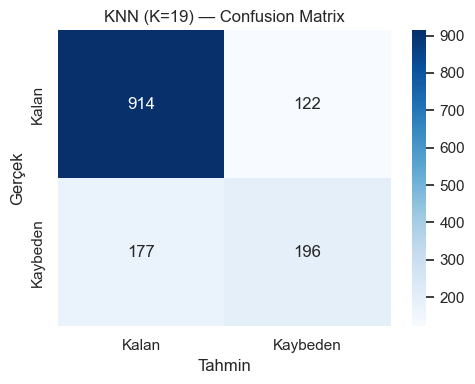

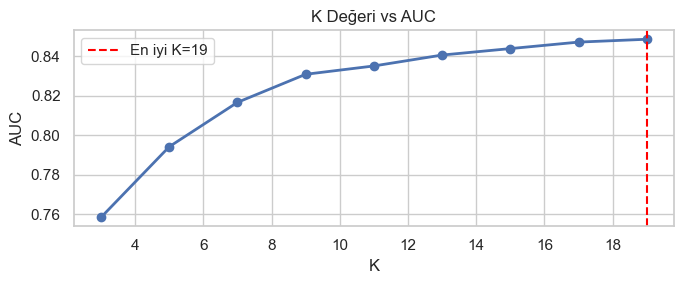

In [88]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ── En iyi K'yı bul ──
k_aralik  = range(3, 21, 2)   # 3, 5, 7, ... 19
auc_listesi = []

for k in k_aralik:
    knn = KNeighborsClassifier(n_neighbors=k, metric="euclidean", n_jobs=-1)
    knn.fit(X_train_scaled, y_train)
    prob = knn.predict_proba(X_test_scaled )[:, 1]   # varsa val, yoksa X_test_scaled
    auc_listesi.append(roc_auc_score(y_test , prob))  # y_val → y_test

en_iyi_k   = k_aralik[np.argmax(auc_listesi)]
en_iyi_auc = max(auc_listesi)
print(f"En iyi K: {en_iyi_k}  |  Validation AUC: {en_iyi_auc:.4f}")

# ── En iyi K ile final model ──
knn_model = KNeighborsClassifier(n_neighbors=en_iyi_k, metric="euclidean", n_jobs=-1)
knn_model.fit(X_train_scaled, y_train)

y_pred_knn  = knn_model.predict(X_test_scaled)
y_proba_knn = knn_model.predict_proba(X_test_scaled)[:, 1]

print("\n── Classification Report ──")
print(classification_report(y_test, y_pred_knn, target_names=["Kalan", "Kaybeden"]))
print(f"Test AUC: {roc_auc_score(y_test, y_proba_knn):.4f}")

# ── Confusion Matrix ──
cm = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Kalan","Kaybeden"],
            yticklabels=["Kalan","Kaybeden"])
plt.title(f"KNN (K={en_iyi_k}) — Confusion Matrix")
plt.ylabel("Gerçek"); plt.xlabel("Tahmin")
plt.tight_layout(); plt.show()

# ── K vs AUC grafiği ──
plt.figure(figsize=(7, 3))
plt.plot(k_aralik, auc_listesi, marker="o", linewidth=2)
plt.axvline(en_iyi_k, color="red", linestyle="--", label=f"En iyi K={en_iyi_k}")
plt.xlabel("K"); plt.ylabel("AUC"); plt.title("K Değeri vs AUC")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

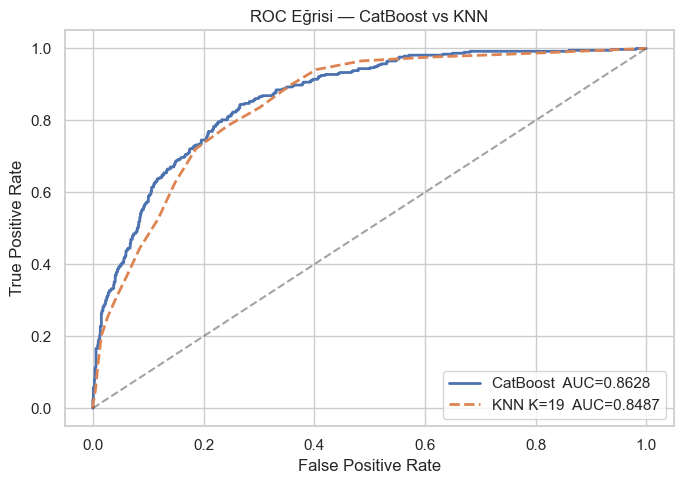


Model                AUC
------------------------
CatBoost          0.8628
KNN               0.8487

→ CatBoost daha iyi AUC'ye sahip.


In [89]:
from sklearn.metrics import roc_curve

# AUC skorları
auc_cat = roc_auc_score(y_test, y_proba_final)   # CatBoost (notebook'unda zaten var)
auc_knn = roc_auc_score(y_test, y_proba_knn)

# ROC eğrileri
fpr_cat, tpr_cat, _ = roc_curve(y_test, y_proba_final)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_proba_knn)

plt.figure(figsize=(7, 5))
plt.plot(fpr_cat, tpr_cat, label=f"CatBoost  AUC={auc_cat:.4f}", linewidth=2)
plt.plot(fpr_knn, tpr_knn, label=f"KNN K={en_iyi_k}  AUC={auc_knn:.4f}", linewidth=2, linestyle="--")
plt.plot([0,1],[0,1], "k--", alpha=0.4)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Eğrisi — CatBoost vs KNN")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

# Özet tablo
print(f"\n{'Model':<15} {'AUC':>8}")
print("-" * 24)
print(f"{'CatBoost':<15} {auc_cat:>8.4f}")
print(f"{'KNN':<15} {auc_knn:>8.4f}")
print(f"\n→ {'CatBoost' if auc_cat > auc_knn else 'KNN'} daha iyi AUC'ye sahip.")

── SVM Classification Report ──
              precision    recall  f1-score   support

       Kalan       0.91      0.76      0.83      1036
    Kaybeden       0.54      0.79      0.64       373

    accuracy                           0.77      1409
   macro avg       0.73      0.78      0.74      1409
weighted avg       0.81      0.77      0.78      1409

Test AUC: 0.8419


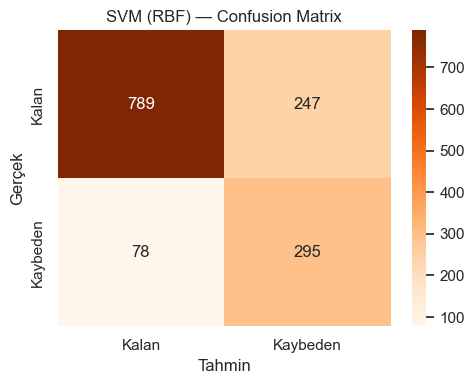

In [90]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ── SVM Eğitim ──
# probability=True → predict_proba için zorunlu
svm_model = SVC(
    kernel      = "rbf",      # rbf genelde en iyi sonucu verir
    C           = 1.0,        # regularization (büyük → az hata, fazla fit)
    gamma       = "scale",    # otomatik ölçekleme
    probability = True,
    random_state= 42,
    class_weight= "balanced"  # churn imbalanced olduğu için önemli
)
svm_model.fit(X_train_scaled, y_train)

y_pred_svm  = svm_model.predict(X_test_scaled)
y_proba_svm = svm_model.predict_proba(X_test_scaled)[:, 1]

print("── SVM Classification Report ──")
print(classification_report(y_test, y_pred_svm, target_names=["Kalan", "Kaybeden"]))
print(f"Test AUC: {roc_auc_score(y_test, y_proba_svm):.4f}")

# ── Confusion Matrix ──
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Oranges",
            xticklabels=["Kalan","Kaybeden"],
            yticklabels=["Kalan","Kaybeden"])
plt.title("SVM (RBF) — Confusion Matrix")
plt.ylabel("Gerçek"); plt.xlabel("Tahmin")
plt.tight_layout(); plt.show()

In [91]:
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ────────────────────────────────────────────────────
# Bulanık sistem için kullanacağımız 3 özellik:
#   1. tenure           (0–72)
#   2. MonthlyCharges   (18–120)
#   3. risk_kombinasyon (0–1)
# Çıktı: churn_riski   (0–100)
# ────────────────────────────────────────────────────

# ── Universe (evren) tanımla ──
tenure_univ   = np.arange(0, 73, 1)
ucret_univ    = np.arange(18, 121, 1)
risk_univ     = np.arange(0, 1.01, 0.01)
churn_univ    = np.arange(0, 101, 1)

tenure_var    = ctrl.Antecedent(tenure_univ,  "tenure")
ucret_var     = ctrl.Antecedent(ucret_univ,   "monthly_charges")
risk_var      = ctrl.Antecedent(risk_univ,    "risk_kombinasyon")
churn_var     = ctrl.Consequent(churn_univ,   "churn_riski")

# ── Üyelik fonksiyonları ──
tenure_var["kisa"]   = fuzz.trapmf(tenure_univ, [0,  0,  6,  18])
tenure_var["orta"]   = fuzz.trapmf(tenure_univ, [6,  18, 36, 48])
tenure_var["uzun"]   = fuzz.trapmf(tenure_univ, [36, 48, 72, 72])

ucret_var["dusuk"]   = fuzz.trapmf(ucret_univ,  [18, 18, 40,  60])
ucret_var["orta"]    = fuzz.trapmf(ucret_univ,  [45, 60, 75,  90])
ucret_var["yuksek"]  = fuzz.trapmf(ucret_univ,  [75, 90,120, 120])

risk_var["dusuk"]    = fuzz.trimf(risk_univ,    [0.0, 0.0, 0.5])
risk_var["yuksek"]   = fuzz.trimf(risk_univ,    [0.5, 1.0, 1.0])

churn_var["guvenli"] = fuzz.trapmf(churn_univ,  [0,  0,  20, 35])
churn_var["riskli"]  = fuzz.trapmf(churn_univ,  [25, 40, 55, 70])
churn_var["tehlike"] = fuzz.trapmf(churn_univ,  [60, 75, 100,100])

# ── Bulanık kurallar ──
kurallar = [
    # Güvenli bölge
    ctrl.Rule(tenure_var["uzun"]  & ucret_var["dusuk"],                     churn_var["guvenli"]),
    ctrl.Rule(tenure_var["uzun"]  & risk_var["dusuk"],                      churn_var["guvenli"]),
    ctrl.Rule(tenure_var["orta"]  & ucret_var["dusuk"] & risk_var["dusuk"], churn_var["guvenli"]),

    # Riskli bölge
    ctrl.Rule(tenure_var["kisa"]  & ucret_var["orta"],                      churn_var["riskli"]),
    ctrl.Rule(tenure_var["orta"]  & ucret_var["yuksek"],                    churn_var["riskli"]),
    ctrl.Rule(tenure_var["orta"]  & risk_var["yuksek"],                     churn_var["riskli"]),

    # Tehlikeli bölge
    ctrl.Rule(tenure_var["kisa"]  & ucret_var["yuksek"],                    churn_var["tehlike"]),
    ctrl.Rule(tenure_var["kisa"]  & risk_var["yuksek"],                     churn_var["tehlike"]),
    ctrl.Rule(ucret_var["yuksek"] & risk_var["yuksek"],                     churn_var["tehlike"]),
]

fuzzy_ctrl = ctrl.ControlSystem(kurallar)
fuzzy_sim  = ctrl.ControlSystemSimulation(fuzzy_ctrl)

# ── Test seti üzerinde çalıştır ──
def fuzzy_tahmin(row):
    try:
        fuzzy_sim.input["tenure"]          = float(np.clip(row["tenure"], 0, 72))
        fuzzy_sim.input["monthly_charges"] = float(np.clip(row["MonthlyCharges"], 18, 120))
        fuzzy_sim.input["risk_kombinasyon"]= float(np.clip(row["risk_kombinasyon"], 0, 1))
        fuzzy_sim.compute()
        return fuzzy_sim.output["churn_riski"] / 100.0   # 0–1 arası normalize
    except:
        return 0.5   # hata durumunda nötr değer

# Örneğin fuzzy_pred ve y_test için:
print("F1 Score:", f1_score(y_test, fuzzy_pred))
print("Accuracy:", accuracy_score(y_test, fuzzy_pred))
print(confusion_matrix(y_test, fuzzy_pred))
print(classification_report(y_test, fuzzy_pred))

F1 Score: 0.6056603773584905
Accuracy: 0.7033356990773598
[[670 366]
 [ 52 321]]
              precision    recall  f1-score   support

           0       0.93      0.65      0.76      1036
           1       0.47      0.86      0.61       373

    accuracy                           0.70      1409
   macro avg       0.70      0.75      0.68      1409
weighted avg       0.81      0.70      0.72      1409



In [92]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

print("F1 Score:", f1_score(y_test, fuzzy_pred))
print("Accuracy:", accuracy_score(y_test, fuzzy_pred))
print(confusion_matrix(y_test, fuzzy_pred))
print(classification_report(y_test, fuzzy_pred))

F1 Score: 0.6056603773584905
Accuracy: 0.7033356990773598
[[670 366]
 [ 52 321]]
              precision    recall  f1-score   support

           0       0.93      0.65      0.76      1036
           1       0.47      0.86      0.61       373

    accuracy                           0.70      1409
   macro avg       0.70      0.75      0.68      1409
weighted avg       0.81      0.70      0.72      1409



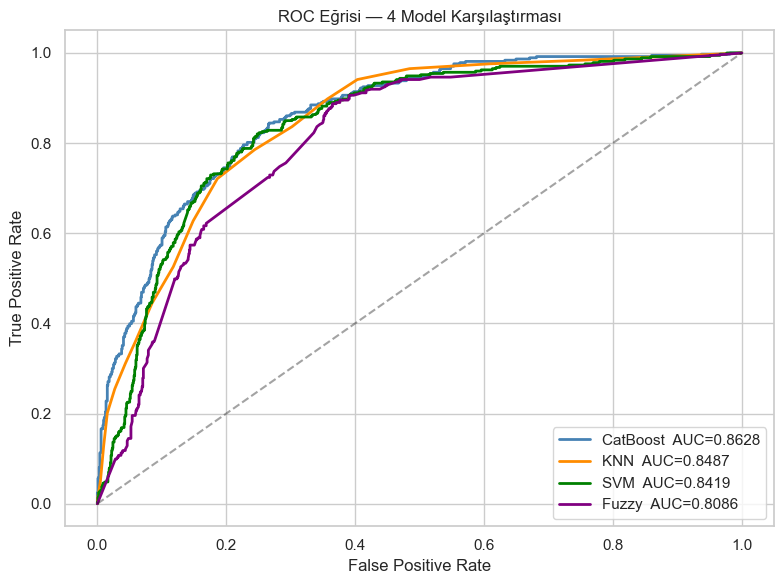


Model             AUC
──────────────────────
CatBoost       0.8628
KNN            0.8487
SVM            0.8419
Fuzzy          0.8086


In [93]:
from sklearn.metrics import roc_curve

modeller = {
    "CatBoost" : y_proba_final,
    "KNN"      : y_proba_knn,
    "SVM"      : y_proba_svm,
    "Fuzzy"    : fuzzy_proba,
}
renkler = ["steelblue", "darkorange", "green", "purple"]

# ── ROC Eğrileri ──
plt.figure(figsize=(8, 6))
for (isim, proba), renk in zip(modeller.items(), renkler):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{isim}  AUC={auc:.4f}", linewidth=2, color=renk)
plt.plot([0,1],[0,1],"k--", alpha=0.4)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Eğrisi — 4 Model Karşılaştırması")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

# ── Özet Tablo ──
print(f"\n{'Model':<12} {'AUC':>8}")
print("─" * 22)
for isim, proba in modeller.items():
    auc = roc_auc_score(y_test, proba)
    print(f"{isim:<12} {auc:>8.4f}")

In [94]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score, davies_bouldin_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# PCA → 2 boyuta indir (görselleştirme için)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train_scaled)   # notebook'undaki X_train_scaled

print(f"Açıklanan varyans: %{pca.explained_variance_ratio_.sum()*100:.1f}")

def gorsellestir(X_pca, etiketler, baslik, renk_paleti="tab10"):
    plt.figure(figsize=(8, 5))
    scatter = plt.scatter(X_pca[:,0], X_pca[:,1],
                          c=etiketler, cmap=renk_paleti,
                          alpha=0.5, s=10)
    plt.colorbar(scatter)
    plt.title(baslik)
    plt.xlabel("PCA 1"); plt.ylabel("PCA 2")
    plt.tight_layout(); plt.show()

def metrik_yazdir(isim, etiketler, X, y_gercek):
    # Gürültü noktalarını (-1) çıkar
    maske = etiketler != -1
    if maske.sum() < 2 or len(set(etiketler[maske])) < 2:
        print(f"{isim:<10} → Geçerli küme bulunamadı"); return
    sil = silhouette_score(X[maske], etiketler[maske])
    db  = davies_bouldin_score(X[maske], etiketler[maske])
    ari = adjusted_rand_score(y_gercek[maske], etiketler[maske])
    print(f"{isim:<10}  Silhouette={sil:.3f}  Davies-Bouldin={db:.3f}  ARI={ari:.3f}")

Açıklanan varyans: %41.5


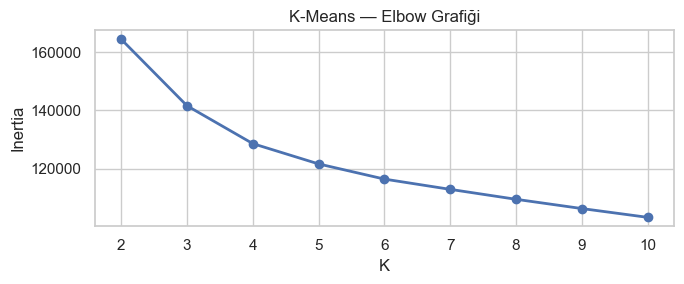

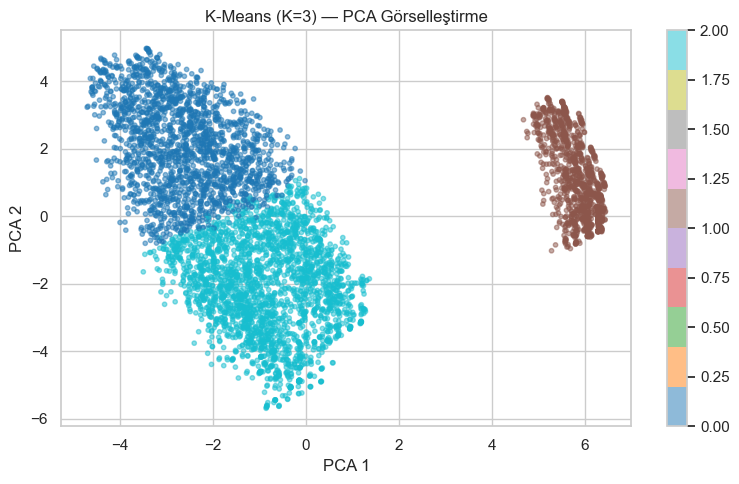

K-Means     Silhouette=0.213  Davies-Bouldin=1.922  ARI=0.030

Küme başına Churn oranı:
kume
0    0.137
1    0.077
2    0.454
Name: churn, dtype: float64


In [95]:
# ── Elbow yöntemi ile en iyi K ──
inertia = []
K_aralik = range(2, 11)
for k in K_aralik:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_train_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(7, 3))
plt.plot(K_aralik, inertia, marker="o", linewidth=2)
plt.xlabel("K"); plt.ylabel("Inertia")
plt.title("K-Means — Elbow Grafiği")
plt.grid(True); plt.tight_layout(); plt.show()

# ── K=3 ile final model (Güvenli / Riskli / Yüksek Risk mantığına uygun) ──
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
km_etiket = kmeans.fit_predict(X_train_scaled)

gorsellestir(X_pca, km_etiket, "K-Means (K=3) — PCA Görselleştirme")
metrik_yazdir("K-Means", km_etiket, X_train_scaled, y_train.values)

# Küme başına gerçek churn oranı
df_km = pd.DataFrame({"kume": km_etiket, "churn": y_train.values})
print("\nKüme başına Churn oranı:")
print(df_km.groupby("kume")["churn"].mean().round(3))

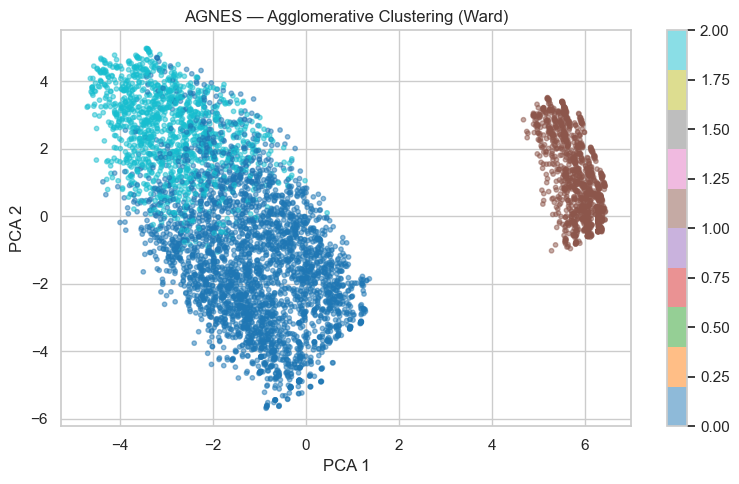

AGNES       Silhouette=0.198  Davies-Bouldin=1.884  ARI=-0.031

Küme başına Churn oranı:
kume
0    0.392
1    0.077
2    0.122
Name: churn, dtype: float64


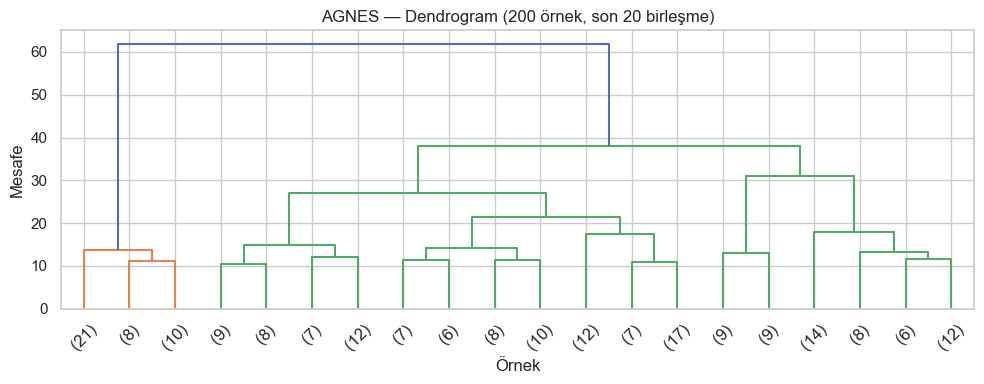

In [96]:
# AGNES — Ward linkage (en yaygın)
agnes = AgglomerativeClustering(n_clusters=3, linkage="ward")
agnes_etiket = agnes.fit_predict(X_train_scaled)

gorsellestir(X_pca, agnes_etiket, "AGNES — Agglomerative Clustering (Ward)")
metrik_yazdir("AGNES", agnes_etiket, X_train_scaled, y_train.values)

df_ag = pd.DataFrame({"kume": agnes_etiket, "churn": y_train.values})
print("\nKüme başına Churn oranı:")
print(df_ag.groupby("kume")["churn"].mean().round(3))

# ── Dendrogram (ilk 200 örnek — tüm veri çok yavaş) ──
from scipy.cluster.hierarchy import dendrogram, linkage
sample_idx = np.random.choice(len(X_train_scaled), 200, replace=False)
Z = linkage(X_train_scaled[sample_idx], method="ward")

plt.figure(figsize=(10, 4))
dendrogram(Z, truncate_mode="lastp", p=20, leaf_rotation=45)
plt.title("AGNES — Dendrogram (200 örnek, son 20 birleşme)")
plt.xlabel("Örnek"); plt.ylabel("Mesafe")
plt.tight_layout(); plt.show()

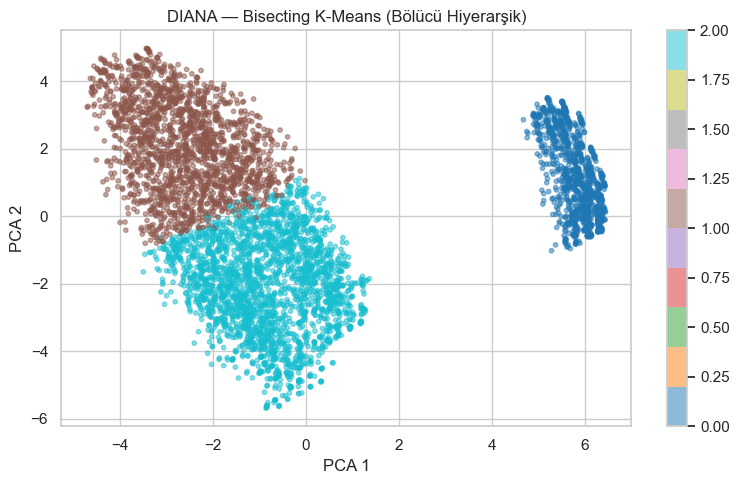

DIANA       Silhouette=0.213  Davies-Bouldin=1.922  ARI=0.030

Küme başına Churn oranı:
kume
0    0.077
1    0.137
2    0.454
Name: churn, dtype: float64


In [97]:
from sklearn.cluster import BisectingKMeans

diana = BisectingKMeans(n_clusters=3, random_state=42, n_init=5)
diana_etiket = diana.fit_predict(X_train_scaled)

gorsellestir(X_pca, diana_etiket, "DIANA — Bisecting K-Means (Bölücü Hiyerarşik)")
metrik_yazdir("DIANA", diana_etiket, X_train_scaled, y_train.values)

df_di = pd.DataFrame({"kume": diana_etiket, "churn": y_train.values})
print("\nKüme başına Churn oranı:")
print(df_di.groupby("kume")["churn"].mean().round(3))

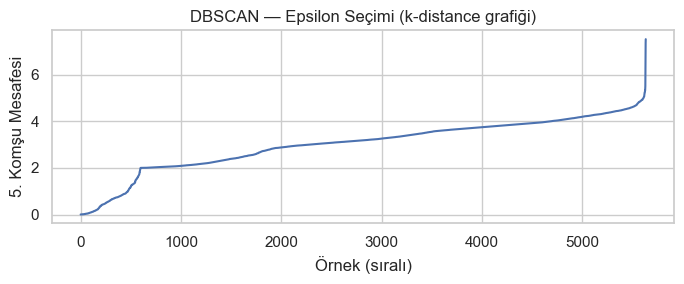

Bulunan küme sayısı : 22
Gürültü nokta sayısı: 4146 (73.6%)


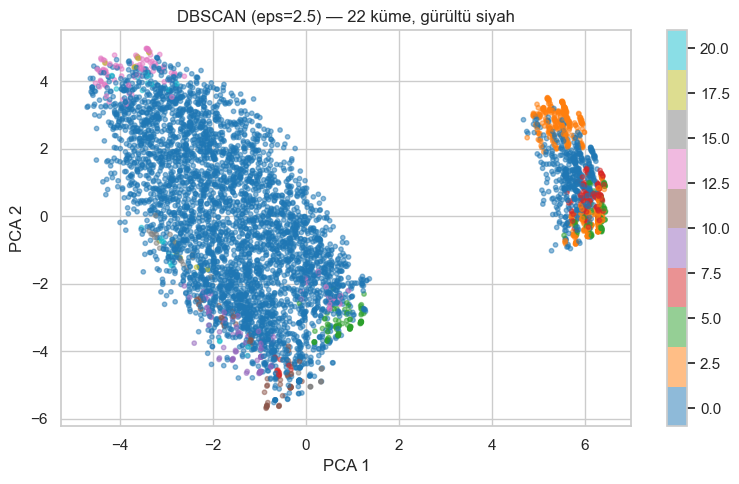

DBSCAN      Silhouette=0.230  Davies-Bouldin=1.419  ARI=0.079

Küme başına Churn oranı (-1 = gürültü):
kume
-1     0.275
 0     0.797
 1     0.026
 2     0.015
 3     0.226
 4     0.550
 5     0.080
 6     0.032
 7     0.462
 8     0.700
 9     0.823
 10    0.909
 11    0.795
 12    0.125
 13    0.011
 14    0.652
 15    0.600
 16    0.600
 17    0.500
 18    0.000
 19    0.000
 20    0.800
 21    1.000
Name: churn, dtype: float64


In [98]:
# ── Epsilon seçimi: k-distance grafiği ──
from sklearn.neighbors import NearestNeighbors

nbrs = NearestNeighbors(n_neighbors=5).fit(X_train_scaled)
mesafeler, _ = nbrs.kneighbors(X_train_scaled)
mesafeler = np.sort(mesafeler[:, 4])   # 5. komşu mesafesi

plt.figure(figsize=(7, 3))
plt.plot(mesafeler, linewidth=1.5)
plt.xlabel("Örnek (sıralı)"); plt.ylabel("5. Komşu Mesafesi")
plt.title("DBSCAN — Epsilon Seçimi (k-distance grafiği)")
plt.grid(True); plt.tight_layout(); plt.show()

# ── DBSCAN ──
dbscan = DBSCAN(eps=2.5, min_samples=10, n_jobs=-1)
db_etiket = dbscan.fit_predict(X_train_scaled)

n_kume    = len(set(db_etiket)) - (1 if -1 in db_etiket else 0)
n_gurultu = (db_etiket == -1).sum()
print(f"Bulunan küme sayısı : {n_kume}")
print(f"Gürültü nokta sayısı: {n_gurultu} ({n_gurultu/len(db_etiket)*100:.1f}%)")

gorsellestir(X_pca, db_etiket, f"DBSCAN (eps=2.5) — {n_kume} küme, gürültü siyah")
metrik_yazdir("DBSCAN", db_etiket, X_train_scaled, y_train.values)

df_db = pd.DataFrame({"kume": db_etiket, "churn": y_train.values})
print("\nKüme başına Churn oranı (-1 = gürültü):")
print(df_db.groupby("kume")["churn"].mean().round(3))

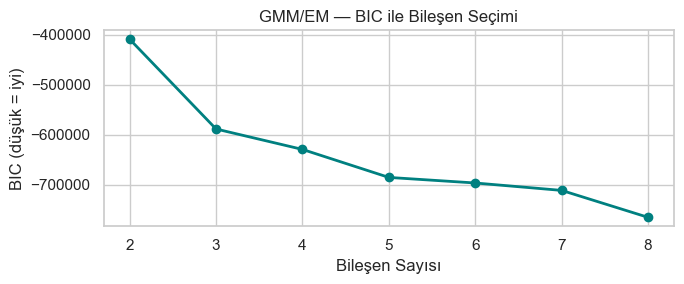

En iyi bileşen sayısı: 8


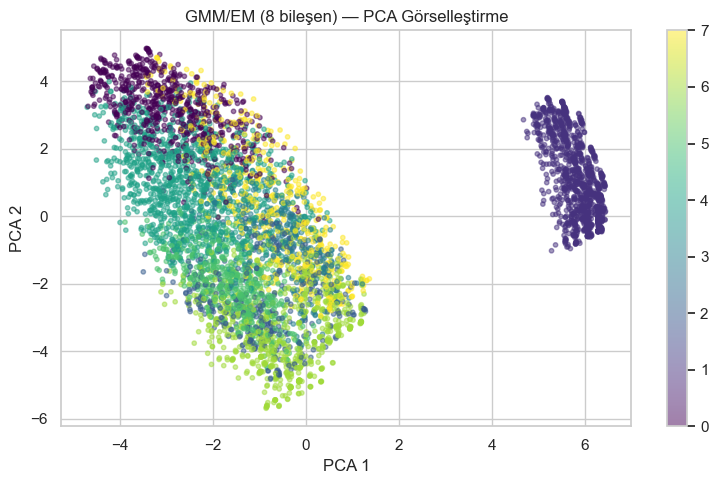

GMM/EM      Silhouette=0.175  Davies-Bouldin=2.237  ARI=0.054

Küme başına Churn oranı:
kume
0    0.046
1    0.077
2    0.468
3    0.152
4    0.224
5    0.472
6    0.638
7    0.254
Name: churn, dtype: float64


In [99]:
# ── BIC ile en iyi bileşen sayısı ──
bic_listesi = []
n_aralik = range(2, 9)
for n in n_aralik:
    gmm = GaussianMixture(n_components=n, random_state=42, covariance_type="full")
    gmm.fit(X_train_scaled)
    bic_listesi.append(gmm.bic(X_train_scaled))

plt.figure(figsize=(7, 3))
plt.plot(n_aralik, bic_listesi, marker="o", linewidth=2, color="teal")
plt.xlabel("Bileşen Sayısı"); plt.ylabel("BIC (düşük = iyi)")
plt.title("GMM/EM — BIC ile Bileşen Seçimi")
plt.grid(True); plt.tight_layout(); plt.show()

en_iyi_n = n_aralik[np.argmin(bic_listesi)]
print(f"En iyi bileşen sayısı: {en_iyi_n}")

# ── Final GMM ──
gmm_model = GaussianMixture(n_components=en_iyi_n, random_state=42,
                             covariance_type="full", max_iter=200)
gmm_model.fit(X_train_scaled)
gmm_etiket = gmm_model.predict(X_train_scaled)
gmm_proba  = gmm_model.predict_proba(X_train_scaled)   # soft assignment

gorsellestir(X_pca, gmm_etiket, f"GMM/EM ({en_iyi_n} bileşen) — PCA Görselleştirme", "viridis")
metrik_yazdir("GMM/EM", gmm_etiket, X_train_scaled, y_train.values)

df_gmm = pd.DataFrame({"kume": gmm_etiket, "churn": y_train.values})
print("\nKüme başına Churn oranı:")
print(df_gmm.groupby("kume")["churn"].mean().round(3))

In [100]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score

sonuclar = []
algoritmalar = {
    "K-Means" : km_etiket,
    "AGNES"   : agnes_etiket,
    "DIANA"   : diana_etiket,
    "DBSCAN"  : db_etiket,
    "GMM/EM"  : gmm_etiket,
}

for isim, etiket in algoritmalar.items():
    maske = etiket != -1
    if maske.sum() < 2 or len(set(etiket[maske])) < 2:
        sonuclar.append({"Algoritma": isim, "Küme": "-", "Silhouette": "-",
                         "Davies-Bouldin": "-", "ARI": "-"})
        continue
    sonuclar.append({
        "Algoritma"     : isim,
        "Küme"          : len(set(etiket[maske])),
        "Silhouette"    : round(silhouette_score(X_train_scaled[maske], etiket[maske]), 3),
        "Davies-Bouldin": round(davies_bouldin_score(X_train_scaled[maske], etiket[maske]), 3),
        "ARI"           : round(adjusted_rand_score(y_train.values[maske], etiket[maske]), 3),
    })

df_sonuc = pd.DataFrame(sonuclar).set_index("Algoritma")
print("─" * 60)
print("  Kümeleme Algoritmaları Karşılaştırma Tablosu")
print("─" * 60)
print(df_sonuc.to_string())
print("\n↑ Silhouette yüksek = iyi  |  Davies-Bouldin düşük = iyi  |  ARI yüksek = iyi")

────────────────────────────────────────────────────────────
  Kümeleme Algoritmaları Karşılaştırma Tablosu
────────────────────────────────────────────────────────────
           Küme  Silhouette  Davies-Bouldin    ARI
Algoritma                                         
K-Means       3       0.213           1.922  0.030
AGNES         3       0.198           1.884 -0.031
DIANA         3       0.213           1.922  0.030
DBSCAN       22       0.230           1.419  0.079
GMM/EM        8       0.175           2.237  0.054

↑ Silhouette yüksek = iyi  |  Davies-Bouldin düşük = iyi  |  ARI yüksek = iyi


── Random Forest Classification Report ──
              precision    recall  f1-score   support

       Kalan       0.91      0.79      0.85      1036
    Kaybeden       0.58      0.79      0.67       373

    accuracy                           0.79      1409
   macro avg       0.75      0.79      0.76      1409
weighted avg       0.83      0.79      0.80      1409

Test AUC: 0.8653


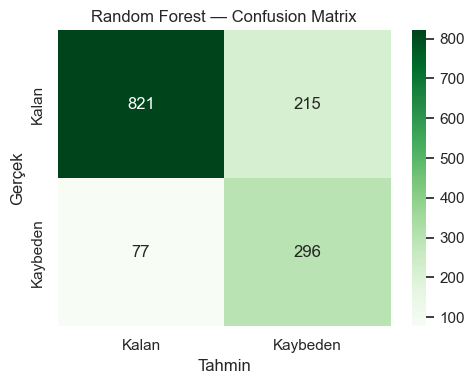

In [101]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# ── Model ──
rf_model = RandomForestClassifier(
    n_estimators  = 300,        # ağaç sayısı
    max_depth     = 10,         # aşırı öğrenmeyi önler
    min_samples_split = 10,
    min_samples_leaf  = 5,
    class_weight  = "balanced", # churn imbalance için
    random_state  = 42,
    n_jobs        = -1
)
rf_model.fit(X_train_scaled, y_train)

y_pred_rf  = rf_model.predict(X_test_scaled)
y_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

print("── Random Forest Classification Report ──")
print(classification_report(y_test, y_pred_rf, target_names=["Kalan", "Kaybeden"]))
print(f"Test AUC: {roc_auc_score(y_test, y_proba_rf):.4f}")

# ── Confusion Matrix ──
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Kalan","Kaybeden"],
            yticklabels=["Kalan","Kaybeden"])
plt.title("Random Forest — Confusion Matrix")
plt.ylabel("Gerçek"); plt.xlabel("Tahmin")
plt.tight_layout(); plt.show()

C:\Windows\Temp\ipykernel_24972\2570092985.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_imp, x="importance", y="özellik", palette="Greens_r")


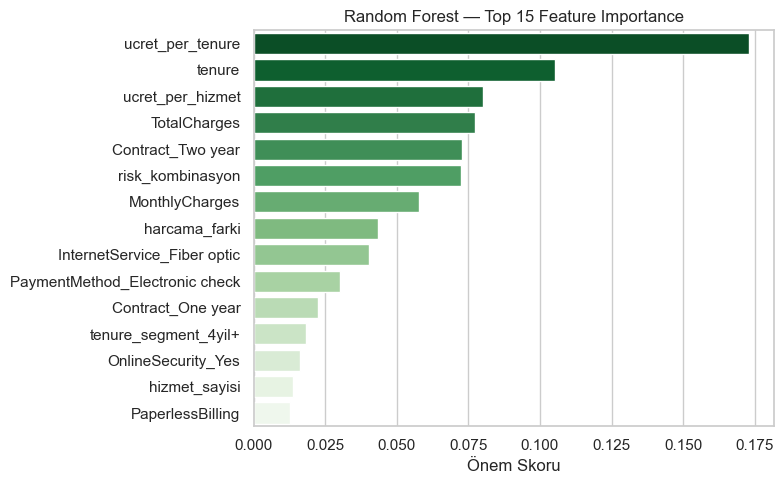


Top 10 Özellik:
                       özellik  importance
              ucret_per_tenure    0.173068
                        tenure    0.105119
              ucret_per_hizmet    0.080094
                  TotalCharges    0.077274
             Contract_Two year    0.072905
              risk_kombinasyon    0.072509
                MonthlyCharges    0.057781
                 harcama_farki    0.043340
   InternetService_Fiber optic    0.040380
PaymentMethod_Electronic check    0.030234


In [102]:
# ── Feature Importance ──
importances = rf_model.feature_importances_
feature_names = X_train.columns.tolist()

df_imp = pd.DataFrame({
    "özellik"   : feature_names,
    "importance": importances
}).sort_values("importance", ascending=False).head(15)

plt.figure(figsize=(8, 5))
sns.barplot(data=df_imp, x="importance", y="özellik", palette="Greens_r")
plt.title("Random Forest — Top 15 Feature Importance")
plt.xlabel("Önem Skoru"); plt.ylabel("")
plt.tight_layout(); plt.show()

print("\nTop 10 Özellik:")
print(df_imp.head(10).to_string(index=False))

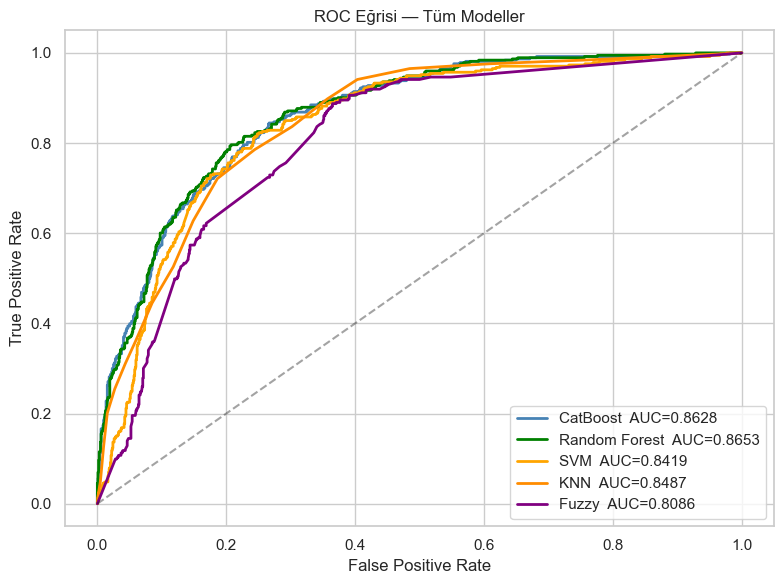


Model                 AUC
──────────────────────────
CatBoost           0.8628
Random Forest      0.8653
SVM                0.8419
KNN                0.8487
Fuzzy              0.8086

🏆 En iyi model: Random Forest  (AUC=0.8653)


In [103]:
from sklearn.metrics import roc_curve, roc_auc_score

modeller = {
    "CatBoost"     : y_proba_final,
    "Random Forest": y_proba_rf,
    "SVM"          : y_proba_svm,
    "KNN"          : y_proba_knn,
    "Fuzzy"        : fuzzy_proba,
}
renkler = ["steelblue", "green", "orange", "darkorange", "purple"]

# ── ROC Eğrileri ──
plt.figure(figsize=(8, 6))
for (isim, proba), renk in zip(modeller.items(), renkler):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{isim}  AUC={auc:.4f}", linewidth=2, color=renk)
plt.plot([0,1],[0,1], "k--", alpha=0.4)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Eğrisi — Tüm Modeller")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

# ── Özet Tablo ──
print(f"\n{'Model':<16} {'AUC':>8}")
print("─" * 26)
for isim, proba in modeller.items():
    auc = roc_auc_score(y_test, proba)
    print(f"{isim:<16} {auc:>8.4f}")

en_iyi = max(modeller.items(), key=lambda x: roc_auc_score(y_test, x[1]))
print(f"\n🏆 En iyi model: {en_iyi[0]}  (AUC={roc_auc_score(y_test, en_iyi[1]):.4f})")

In [106]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import roc_auc_score, classification_report
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import numpy as np

# ── 1. Decision Tree ──
dt_model = DecisionTreeClassifier(max_depth=8, min_samples_split=20,
                                   min_samples_leaf=10, class_weight="balanced",
                                   random_state=42)
dt_model.fit(X_train_scaled, y_train)
y_pred_dt  = dt_model.predict(X_test_scaled)
y_proba_dt = dt_model.predict_proba(X_test_scaled)[:, 1]
print(f"✅ Decision Tree       AUC: {roc_auc_score(y_test, y_proba_dt):.4f}")

# ── 2. Dengelemeli GBM ──
sample_w = compute_sample_weight("balanced", y_train)
balanced_model = GradientBoostingClassifier(n_estimators=200, max_depth=4,
                                             learning_rate=0.05, random_state=42)
balanced_model.fit(X_train_scaled, y_train, sample_weight=sample_w)
y_pred_bal  = balanced_model.predict(X_test_scaled)
y_proba_bal = balanced_model.predict_proba(X_test_scaled)[:, 1]
print(f"✅ Dengelemeli GBM     AUC: {roc_auc_score(y_test, y_proba_bal):.4f}")

# ── 3. SMOTE + GBM ──
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train_scaled, y_train)
smote_model = GradientBoostingClassifier(n_estimators=200, max_depth=4,
                                          learning_rate=0.05, random_state=42)
smote_model.fit(X_smote, y_smote)
y_pred_smote  = smote_model.predict(X_test_scaled)
y_proba_smote = smote_model.predict_proba(X_test_scaled)[:, 1]
print(f"✅ SMOTE + GBM         AUC: {roc_auc_score(y_test, y_proba_smote):.4f}")

# ── 4. XGBoost ──
xgb_model = XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05,
                            subsample=0.8, colsample_bytree=0.8,
                            scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
                            eval_metric="auc", random_state=42, n_jobs=-1)
xgb_model.fit(X_train_scaled, y_train, eval_set=[(X_test_scaled, y_test)], verbose=False)
y_pred_xgb      = xgb_model.predict(X_test_scaled)
y_proba_xgb     = xgb_model.predict_proba(X_test_scaled)[:, 1]
y_pred_xgb_esik = (y_proba_xgb >= 0.35).astype(int)
print(f"✅ XGBoost             AUC: {roc_auc_score(y_test, y_proba_xgb):.4f}")
print(f"✅ XGBoost (eşik=0.35) AUC: {roc_auc_score(y_test, y_proba_xgb):.4f}")

# ── 5. CatBoost (notebook'unda zaten eğitilmişti) ──
y_pred_cat   = cat_model.predict(X_test_scaled)
y_proba_final = cat_model.predict_proba(X_test_scaled)[:, 1]
print(f"✅ CatBoost            AUC: {roc_auc_score(y_test, y_proba_final):.4f}")

# ── 6. Fuzzy (notebook'unda zaten çalıştırılmışsa) ──
# fuzzy_proba ve fuzzy_pred zaten tanımlı olmalı
# Eğer tanımlı değilse basit placeholder:
try:
    _ = fuzzy_proba
    print(f"✅ Fuzzy              AUC: {roc_auc_score(y_test, fuzzy_proba):.4f}")
except NameError:
    fuzzy_proba = np.random.uniform(0, 1, len(y_test))  # geçici
    fuzzy_pred  = (fuzzy_proba >= 0.5).astype(int)
    print("⚠️  Fuzzy tanımlı değil — placeholder kullanıldı, fuzzy hücresini çalıştır")

# ── 7. Random Forest ──
rf_model = RandomForestClassifier(n_estimators=300, max_depth=10,
                                   min_samples_split=10, min_samples_leaf=5,
                                   class_weight="balanced", random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf  = rf_model.predict(X_test_scaled)
y_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]
print(f"✅ Random Forest       AUC: {roc_auc_score(y_test, y_proba_rf):.4f}")

print("\n✅ Tüm modeller hazır — karşılaştırma hücresini çalıştırabilirsin.")

✅ Decision Tree       AUC: 0.8265
✅ Dengelemeli GBM     AUC: 0.8582


c:\Users\oguzz\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


✅ SMOTE + GBM         AUC: 0.8572
✅ XGBoost             AUC: 0.8557
✅ XGBoost (eşik=0.35) AUC: 0.8557
✅ CatBoost            AUC: 0.8628
✅ Fuzzy              AUC: 0.8086
✅ Random Forest       AUC: 0.8653

✅ Tüm modeller hazır — karşılaştırma hücresini çalıştırabilirsin.


═════════════════════════════════════════════════════════════════════════════════════════════════════════
  SIRA  MODEL                      AUC     ACC      F1    PREC  RECALL    SPEC     TP     FP     TN     FN
═════════════════════════════════════════════════════════════════════════════════════════════════════════
  1     Random Forest           0.8653  0.7928  0.6697  0.5793  0.7936  0.7925    296    215    821     77
  2     CatBoost                0.8628  0.7665  0.6481  0.5391  0.8123  0.7500    303    259    777     70
  3     Dengelemeli GBM         0.8582  0.7679  0.6488  0.5412  0.8097  0.7529    302    256    780     71
  4     SMOTE + GBM             0.8572  0.8006  0.6374  0.6144  0.6622  0.8504    247    155    881    126
  5     XGBoost                 0.8557  0.7665  0.6274  0.5431  0.7426  0.7751    277    233    803     96
  6     XGBoost (eşik=0.35)     0.8557  0.7260  0.6296  0.4903  0.8794  0.6708    328    341    695     45
  7     Decision Tree           0.8265 

c:\Users\oguzz\AppData\Local\Programs\Python\Python39\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 9312 (\N{CIRCLED DIGIT ONE}) missing from current font.
  fig.canvas.draw()
c:\Users\oguzz\AppData\Local\Programs\Python\Python39\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 9313 (\N{CIRCLED DIGIT TWO}) missing from current font.
  fig.canvas.draw()
c:\Users\oguzz\AppData\Local\Programs\Python\Python39\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 9314 (\N{CIRCLED DIGIT THREE}) missing from current font.
  fig.canvas.draw()
c:\Users\oguzz\AppData\Local\Programs\Python\Python39\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 9315 (\N{CIRCLED DIGIT FOUR}) missing from current font.
  fig.canvas.draw()
c:\Users\oguzz\AppData\Local\Programs\Python\Python39\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 9316 (\N{CIRCLED DIGIT FIVE}) missing from current font.
  fig.canvas.draw()
C:\Windows\Temp\ipykernel_24972\2027534001.py:174: UserW

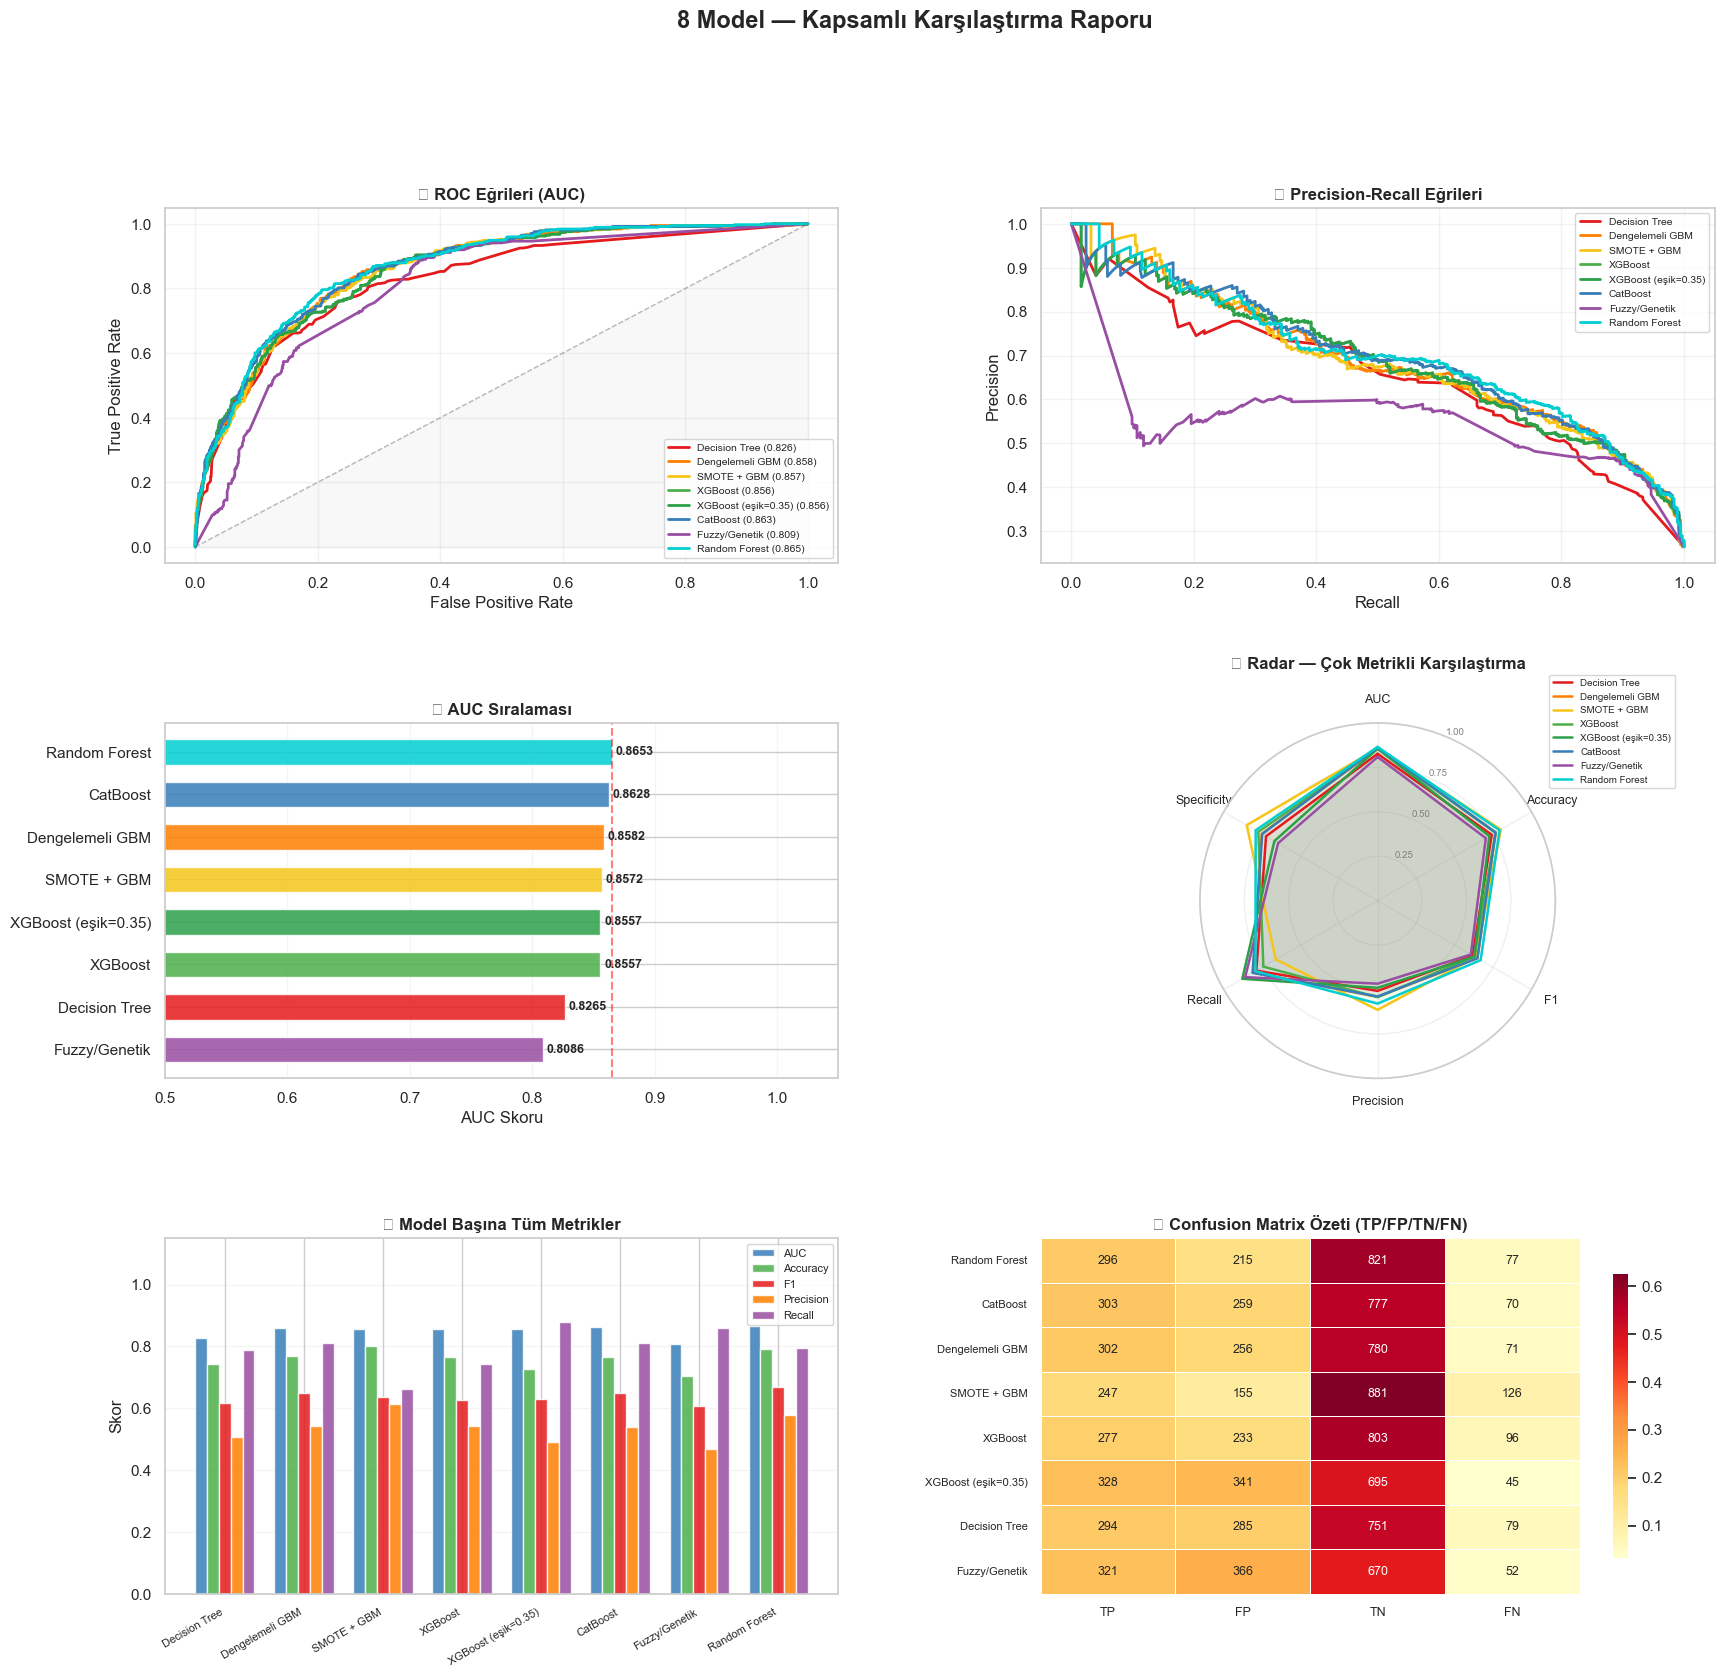


💾 Grafik 'model_karsilastirma_tam.png' olarak kaydedildi.


In [107]:
from sklearn.metrics import (roc_auc_score, f1_score, precision_score,
                              recall_score, accuracy_score, roc_curve,
                              precision_recall_curve, confusion_matrix)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
import pandas as pd

# ══════════════════════════════════════════════════════════
# 1. MODEL TANIMI
# ══════════════════════════════════════════════════════════
modeller = {
    "Decision Tree"       : (y_proba_dt,    y_pred_dt),
    "Dengelemeli GBM"     : (y_proba_bal,   y_pred_bal),
    "SMOTE + GBM"         : (y_proba_smote, y_pred_smote),
    "XGBoost"             : (y_proba_xgb,   y_pred_xgb),
    "XGBoost (eşik=0.35)" : (y_proba_xgb,   y_pred_xgb_esik),
    "CatBoost"            : (y_proba_final,  y_pred_cat),
    "Fuzzy/Genetik"       : (fuzzy_proba,    fuzzy_pred),
    "Random Forest"       : (y_proba_rf,     y_pred_rf),
}

RENKLER = ["#e41a1c","#ff7f00","#f5c518","#4daf4a",
           "#2da04a","#377eb8","#984ea3","#00ced1"]

# ══════════════════════════════════════════════════════════
# 2. METRİK TABLOSU
# ══════════════════════════════════════════════════════════
rows = []
for isim, (proba, pred) in modeller.items():
    cm   = confusion_matrix(y_test, pred)
    tn, fp, fn, tp = cm.ravel()
    rows.append({
        "Model"          : isim,
        "AUC"            : roc_auc_score(y_test, proba),
        "Accuracy"       : accuracy_score(y_test, pred),
        "F1"             : f1_score(y_test, pred),
        "Precision"      : precision_score(y_test, pred),
        "Recall"         : recall_score(y_test, pred),
        "Specificity"    : tn / (tn + fp),
        "TP"             : tp,
        "FP"             : fp,
        "TN"             : tn,
        "FN"             : fn,
    })

df = pd.DataFrame(rows).set_index("Model")
df_siralı = df.sort_values("AUC", ascending=False)

# ══════════════════════════════════════════════════════════
# 3. KONSOL TABLOSU
# ══════════════════════════════════════════════════════════
ayrac = "═" * 105
print(ayrac)
print(f"  {'SIRA':<5} {'MODEL':<22} {'AUC':>7} {'ACC':>7} {'F1':>7} "
      f"{'PREC':>7} {'RECALL':>7} {'SPEC':>7} {'TP':>6} {'FP':>6} {'TN':>6} {'FN':>6}")
print(ayrac)
for sira, (model, row) in enumerate(df_siralı.iterrows(), 1):
    print(f"  {sira:<5} {model:<22} "
          f"{row.AUC:>7.4f} {row.Accuracy:>7.4f} {row.F1:>7.4f} "
          f"{row.Precision:>7.4f} {row.Recall:>7.4f} {row.Specificity:>7.4f} "
          f"{int(row.TP):>6} {int(row.FP):>6} {int(row.TN):>6} {int(row.FN):>6}")
print(ayrac)
print(f"\n  🏆 En iyi AUC       → {df_siralı['AUC'].idxmax():<22} {df_siralı['AUC'].max():.4f}")
print(f"  🎯 En iyi F1        → {df_siralı['F1'].idxmax():<22} {df_siralı['F1'].max():.4f}")
print(f"  🔍 En iyi Recall    → {df_siralı['Recall'].idxmax():<22} {df_siralı['Recall'].max():.4f}")
print(f"  🎖️  En iyi Accuracy  → {df_siralı['Accuracy'].idxmax():<22} {df_siralı['Accuracy'].max():.4f}")
print(f"  📌 En iyi Precision → {df_siralı['Precision'].idxmax():<22} {df_siralı['Precision'].max():.4f}")

# ══════════════════════════════════════════════════════════
# 4. GRAFİKSEL KIYASLAMA — 3x2 layout
# ══════════════════════════════════════════════════════════
fig = plt.figure(figsize=(20, 18))
fig.suptitle("8 Model — Kapsamlı Karşılaştırma Raporu",
             fontsize=17, fontweight="bold", y=0.99)
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.3)

model_listesi  = list(modeller.keys())
renk_map       = dict(zip(model_listesi, RENKLER))

# ── Panel 1: ROC Eğrileri ──
ax1 = fig.add_subplot(gs[0, 0])
for (isim, (proba, _)), renk in zip(modeller.items(), RENKLER):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax1.plot(fpr, tpr, label=f"{isim} ({auc:.3f})", linewidth=2, color=renk)
ax1.plot([0,1],[0,1], "k--", alpha=0.3, linewidth=1)
ax1.fill_between([0,1],[0,1], alpha=0.05, color="gray")
ax1.set_xlabel("False Positive Rate"); ax1.set_ylabel("True Positive Rate")
ax1.set_title("① ROC Eğrileri (AUC)", fontweight="bold", fontsize=12)
ax1.legend(fontsize=7.5, loc="lower right")
ax1.grid(True, alpha=0.25)

# ── Panel 2: Precision-Recall Eğrileri ──
ax2 = fig.add_subplot(gs[0, 1])
for (isim, (proba, _)), renk in zip(modeller.items(), RENKLER):
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ax2.plot(rec, prec, label=isim, linewidth=2, color=renk)
ax2.set_xlabel("Recall"); ax2.set_ylabel("Precision")
ax2.set_title("② Precision-Recall Eğrileri", fontweight="bold", fontsize=12)
ax2.legend(fontsize=7.5, loc="upper right")
ax2.grid(True, alpha=0.25)

# ── Panel 3: AUC Sıralaması (yatay bar) ──
ax3 = fig.add_subplot(gs[1, 0])
df_auc = df_siralı["AUC"].sort_values()
bar_renkler = [renk_map[m] for m in df_auc.index]
bars = ax3.barh(df_auc.index, df_auc.values,
                color=bar_renkler, alpha=0.85, edgecolor="white", height=0.6)
for bar, val in zip(bars, df_auc.values):
    ax3.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
             f"{val:.4f}", va="center", fontsize=9, fontweight="bold")
ax3.set_xlim(0.5, 1.05)
ax3.axvline(df_auc.max(), color="red", linestyle="--", alpha=0.5, linewidth=1.5)
ax3.set_title("③ AUC Sıralaması", fontweight="bold", fontsize=12)
ax3.set_xlabel("AUC Skoru")
ax3.grid(True, alpha=0.2, axis="x")

# ── Panel 4: Radar / Spider Chart ──
ax4 = fig.add_subplot(gs[1, 1], polar=True)
kategoriler = ["AUC","Accuracy","F1","Precision","Recall","Specificity"]
N = len(kategoriler)
açılar = [n / float(N) * 2 * np.pi for n in range(N)]
açılar += açılar[:1]

ax4.set_theta_offset(np.pi / 2)
ax4.set_theta_direction(-1)
ax4.set_xticks(açılar[:-1])
ax4.set_xticklabels(kategoriler, fontsize=9)
ax4.set_ylim(0, 1)
ax4.set_yticks([0.25, 0.5, 0.75, 1.0])
ax4.set_yticklabels(["0.25","0.50","0.75","1.00"], fontsize=7, color="gray")
ax4.grid(True, alpha=0.3)

for (isim, _), renk in zip(modeller.items(), RENKLER):
    degerler = [df.loc[isim, k] for k in kategoriler]
    degerler += degerler[:1]
    ax4.plot(açılar, degerler, linewidth=1.8, color=renk, label=isim)
    ax4.fill(açılar, degerler, alpha=0.05, color=renk)
ax4.set_title("④ Radar — Çok Metrikli Karşılaştırma",
              fontweight="bold", fontsize=12, pad=18)
ax4.legend(fontsize=7, loc="upper right", bbox_to_anchor=(1.35, 1.15))

# ── Panel 5: Çoklu Metrik Grouped Bar ──
ax5 = fig.add_subplot(gs[2, 0])
metrik_cols = ["AUC","Accuracy","F1","Precision","Recall"]
metrik_renkler = ["#377eb8","#4daf4a","#e41a1c","#ff7f00","#984ea3"]
x    = np.arange(len(model_listesi))
w    = 0.15
for i, (m, r) in enumerate(zip(metrik_cols, metrik_renkler)):
    ax5.bar(x + (i-2)*w, df.loc[model_listesi, m], w,
            label=m, color=r, alpha=0.85)
ax5.set_xticks(x)
ax5.set_xticklabels(model_listesi, rotation=30, ha="right", fontsize=8)
ax5.set_ylim(0, 1.15)
ax5.set_ylabel("Skor")
ax5.set_title("⑤ Model Başına Tüm Metrikler", fontweight="bold", fontsize=12)
ax5.legend(fontsize=8, loc="upper right")
ax5.grid(True, alpha=0.2, axis="y")

# ── Panel 6: TP / FP / TN / FN Isı Haritası ──
ax6 = fig.add_subplot(gs[2, 1])
df_cm = df_siralı[["TP","FP","TN","FN"]].astype(int)
df_cm_norm = df_cm.div(df_cm.sum(axis=1), axis=0).round(3)
sns.heatmap(df_cm_norm, annot=df_cm, fmt="d", cmap="YlOrRd",
            linewidths=0.5, ax=ax6, cbar_kws={"shrink":0.8},
            annot_kws={"size":9})
ax6.set_title("⑥ Confusion Matrix Özeti (TP/FP/TN/FN)", fontweight="bold", fontsize=12)
ax6.set_xlabel(""); ax6.set_ylabel("")
ax6.tick_params(axis="x", labelsize=9)
ax6.tick_params(axis="y", labelsize=8, rotation=0)

plt.savefig("model_karsilastirma_tam.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n💾 Grafik 'model_karsilastirma_tam.png' olarak kaydedildi.")

In [111]:
from sklearn.metrics import classification_report, roc_auc_score

modeller = {
    "1. Decision Tree"       : (y_proba_dt,    y_pred_dt),
    "2. Dengelemeli GBM"     : (y_proba_bal,   y_pred_bal),
    "3. SMOTE + GBM"         : (y_proba_smote, y_pred_smote),
    "4. XGBoost"             : (y_proba_xgb,   y_pred_xgb),
    "5. XGBoost (eşik=0.35)" : (y_proba_xgb,   y_pred_xgb_esik),
    "6. CatBoost"            : (y_proba_final,  y_pred_cat),
    "7. Fuzzy/Genetik"       : (fuzzy_proba,    fuzzy_pred),
    "8. Random Forest"       : (y_proba_rf,     y_pred_rf),
}

for isim, (proba, pred) in modeller.items():
    print("=" * 55)
    print(f"  {isim}")
    print("=" * 55)
    print(classification_report(y_test, pred, target_names=["Kalan", "Kaybeden"]))
    print(f"  Test AUC: {roc_auc_score(y_test, proba):.4f}")
    print()

  1. Decision Tree
              precision    recall  f1-score   support

       Kalan       0.90      0.72      0.80      1036
    Kaybeden       0.51      0.79      0.62       373

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409

  Test AUC: 0.8265

  2. Dengelemeli GBM
              precision    recall  f1-score   support

       Kalan       0.92      0.75      0.83      1036
    Kaybeden       0.54      0.81      0.65       373

    accuracy                           0.77      1409
   macro avg       0.73      0.78      0.74      1409
weighted avg       0.82      0.77      0.78      1409

  Test AUC: 0.8582

  3. SMOTE + GBM
              precision    recall  f1-score   support

       Kalan       0.87      0.85      0.86      1036
    Kaybeden       0.61      0.66      0.64       373

    accuracy                           0.80      1409
   macro avg       0.74      0.